In [2]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [3]:
fecha_mes_base='2026-06-01'
tipi_cond1='SAE'
tipi_cond2='SAR'
tipi_cond3='AGENDA'
tb_tipolofia='tTipologia_Cencosud_PPFF'
servidor_01=76
tipi_cod='Codigo'
tipi_resp_cod='R0'
tipi_descrip='DESCRIPCION'
tipi_estado='tipo'
tipi_resp_estado='NO GESTIONADO'
tipi_subdescripcion='SUB_DESCRIPCION'
tnum_tb='tNumeroCenco_Sae'
tnum_dni='CODDOC'
tlista_generada='borrar_prestamo_cencosud'
get_base=since_base_maestra_cencosud_ppff

In [28]:
query = f"""
select distinct NUMERO_DOCUMENTO AS vendor_lead_code,
SUBGESTION as descripcion,telefono as phone_number,
FECHA_LLAMADA as FECHA_ENVIO,TIPO_GESTION as estado from MAEBA.ADM_OBJ_TG.tGestionMesDinersTc
where FECHA_LLAMADA <'2026-06-01' and FECHA_LLAMADA is not null
    """
prueba=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
# print([row['SUBGESTION' ] for row in prueba.select('SUBGESTION').distinct().collect()])


In [ ]:
# query = f"""
#     select 
#         DISTINCT 
#         a.CODDOC as vendor_lead_code,
#         a.CEL01 as phone_number,a.FECHA_ENVIO
#     FROM DANTALION.dbo.Base_Maestra_Cencosud_PPFF a 
#     inner join DANTALION.dbo.Base_Maestra_Cencosud_PPFF_vigente b
#     on a.CODDOC=b.CODDOC
#     WHERE a.CODDOC IS NOT NULL
#     and a.fecha_envio <> '2026-06-01'
#     AND a.CEL01 IS NOT NULL
#     and b.fecha_envio = '2026-06-01'

# """
# df_base_p=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

In [17]:
query = f"""
    select 
        DISTINCT 
        a.CODDOC as vendor_lead_code,
        a.CEL01 as phone_number,a.FECHA_ENVIO
    FROM DANTALION.dbo.Base_Maestra_Cencosud_PPFF a 
    inner join DANTALION.dbo.Base_Maestra_Efectiva_Vigente b
    on a.CODDOC=b.DNI
    WHERE a.CODDOC IS NOT NULL
    and a.fecha_envio <> '2026-06-01'
    AND a.CEL01 IS NOT NULL
    and b.fecha_envio = '2026-06-01'

"""
df_base_p=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

In [29]:

window_spec = Window.partitionBy("vendor_lead_code").orderBy(F.col("FECHA_ENVIO").desc_nulls_last())
prueba = prueba.withColumn("ref1_vici", row_number().over(window_spec))
prueba = prueba.filter(F.col('ref1_vici')==1).drop('ref1_vici')
prueba = prueba.withColumn(
    "meses_diferencia",
    F.floor(
        F.months_between(F.lit('2026-06-01'), F.col("FECHA_ENVIO"))
    )
)

In [39]:
prueba=prueba.filter(F.col('estado')=='CONTACTO EFECTIVO')
prueba=prueba.filter(F.col('descripcion').isin(tipi))
prueba=prueba.dropDuplicates(['vendor_lead_code'])


In [36]:
print([row['descripcion' ] for row in prueba.select('descripcion').distinct().collect()])


['MALA EXPERIENCIA', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL (SEGURO)', 'POR SEGURO DE DESGRAVAMEN ', 'CLIENTE ACEPTO OFERTA TC', 'POR LINEA DE CREDITO', 'TASA DE INTERES ALTA', 'CLIENTE INTERESADO - NO DESEA QUE LE ENVIEN INFORMACIÓN', 'VENTA POR OTRO CANAL', 'CLIENTE SE ACERCARÁ A DC', 'NO BRINDA CONSENTIMIENTO - WHATSAPP', 'DESEA EFECTIVO  - TIENE UN PRESTAMO', 'NO TIENE ACEPTACION', 'CLIENTE ACEPTO OFERTA TC SIN TRANSFERIR', 'AGENDA', 'CLIENTE NO ESCUCHA OFERTA', 'POR MEMBRESÍA', 'NO CALIFICA ENTREGA', 'NO BRINDA CONSENTIMIENTO - TITULAR OCUPADO', 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA', 'CLIENTE ACEPTO OFERTA TC (SEGURO)', 'CLIENTE DESEA QUE NO VUELVAN A LLAMAR', 'ACEPTA ENVIO WHATSAPP', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL  SIN TRANSFERIR', 'NO CALIFICA COMERCIAL', 'NO BRINDA CONSENTIMIENTO', 'PROGRAMA DE RECOMPENSAS', 'NO RECONOCE LA MARCA', 'CLIENTE CORTO SIN ESCUCHAR OFERTA', 'SE ENCUENTRA DE VIAJE', 'NO CONFIA EN VENTA TELEFONICA', 'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPA

In [37]:

tipi=[
 'CLIENTE ACEPTO OFERTA TC + ADICIONAL (SEGURO)',
 'POR SEGURO DE DESGRAVAMEN ',
 'CLIENTE ACEPTO OFERTA TC',
 'POR LINEA DE CREDITO',
 'TASA DE INTERES ALTA',
 'CLIENTE INTERESADO - NO DESEA QUE LE ENVIEN INFORMACIÓN',
 'VENTA POR OTRO CANAL',
 'CLIENTE SE ACERCARÁ A DC',
 'DESEA EFECTIVO  - TIENE UN PRESTAMO',
 'NO TIENE ACEPTACION',
 'CLIENTE ACEPTO OFERTA TC SIN TRANSFERIR',
 'AGENDA',
 'CLIENTE NO ESCUCHA OFERTA',
 'POR MEMBRESÍA',
 'NO CALIFICA ENTREGA',
 'NO BRINDA CONSENTIMIENTO - TITULAR OCUPADO',
 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA',
 'CLIENTE ACEPTO OFERTA TC (SEGURO)',
 'ACEPTA ENVIO WHATSAPP',
 'CLIENTE ACEPTO OFERTA TC + ADICIONAL  SIN TRANSFERIR',
 'NO CALIFICA COMERCIAL',
 'PROGRAMA DE RECOMPENSAS',
 'NO RECONOCE LA MARCA',
 'NO CONFIA EN VENTA TELEFONICA',
 'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPADO',
 'CLIENTE NO ESCUCHA OFERTA - ACEPTA WHATSAPP',
 'PREFIERE SU PROPIO BANCO',
 'TITULAR DESEA QUE VUELVAN A LLAMAR',
 'NO DESEA DAR MOTIVOS',
 'COYUNTURA'
 ]

In [42]:
prueba=prueba.withColumn('lote',when(F.col('meses_diferencia')<2,'cet_00')
.when(F.col('meses_diferencia')<5,'cet_01')
.when(F.col('meses_diferencia').isNull(),'otros')
.otherwise(F.lit('cet_02')))

In [43]:
df_cet.groupBy('lote') \
    .count() \
    .orderBy('lote') \
    .show(30)


+----+-----+
|lote|count|
+----+-----+
+----+-----+



In [23]:
print([row['descripcion' ] for row in df_cet.select('descripcion').distinct().collect()])


['VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'NO DESEA –NO ESPECIFICA MOTIVO', 'ACEPTA OFERTA -VENTA', 'DESEA IR A AGENCIA']


In [ ]:

['VOLVER A LLAMAR',
 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
 'NO UTILIZA (TARJETAS - PRESTAMOS)',
 'OFERTA DE TASA MUY ALTA',
 'OFERTA DE LINEA MUY BAJA',
 'ZONA FUERA DE COBERTURA',
 'NO DESEA –NO ESPECIFICA MOTIVO',
 'ACEPTA OFERTA -VENTA',
 'DESEA IR A AGENCIA']





In [ ]:
def proceso_base(spark,fecha_mes_base,tlista_generada):

    array_contactabilidad = [
            'LLAMADA ELIMINADA POR ERROR EN RED (AUTO)',
            'AUTODIAL NO RESPONDE (AUTO)',
            'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)',
            'TELEFONO OCUPADO / NO CONTESTAN',
            'OCUPADO (AUTO)',
            'ZONA FUERA DE COBERTURA',
            'NO DISCADO',
            'LLAMADA EN COLA (AUTO)',
            'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)',
            'GESTION EN PROCESO (AUTO)',
            'MENSAJE EN CASILLA DE VOZ (AUTO)',
            'AGENTE NO DISPONIBLE (AUTO)',
        ]

    array_interes_seguimiento = [
            'VOLVER A LLAMAR',
            'VOLVER A LLAMAR (TERCERO RELACIONADO)',
            'DESEA IR A AGENCIA',
            'CLIENTE DESEA OTRO PRODUCTO',
        ]

    array_objecion_comercial = [
            'NO UTILIZA (TARJETAS - PRESTAMOS)',
            'OFERTA DE TASA MUY ALTA',
            'NO DESEA PAGAR MEMBRESIA',
            'OFERTA DE LINEA MUY BAJA',
            'NO DESEA –NO ESPECIFICA MOTIVO',
            'NO AUTORIZA CONTINUAR CON LA LLAMADA',
            'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA',
        ]

    array_venta = [
            'ACEPTA OFERTA -VENTA',
            'CLIENTE ACEPTA PRODUCTO',
        ]

    array_no_relanzable = [
            'NO VOLVER A LLAMAR NUNCA MAS',
            'TELEFONO EQUIVOCADO',
            'NUMERO DESCONECTADO (AUTO)',
            'CLIENTE FALLECIO',
            'TELEFONO FUERA DE SERVICIO / NO EXISTE',
        ]

    get_base=since_base_maestra_tc_dinners_maeba

    lista_generada_ml_maeba(spark,fecha_mes_base,get_base,array_contactabilidad,array_interes_seguimiento,array_objecion_comercial,array_venta,array_no_relanzable,tlista_generada)
    print(fecha_mes_base)

def add_dataset_ml(df_nuevo, ruta_parquet, periodo_actual):

    df_nuevo = df_nuevo.copy()
    df_nuevo["periodo"] = df_nuevo["periodo"].astype(str)
    if os.path.exists(ruta_parquet):

        df_hist = pd.read_parquet(ruta_parquet)

        df_hist["periodo"] = df_hist["periodo"].astype(str)

        print("Histórico antes:", df_hist.shape)

        df_hist = df_hist[
            df_hist["periodo"] != str(periodo_actual)
        ].copy()

        print("Histórico sin periodo actual:", df_hist.shape)

        # agregar nuevo periodo
        df_total = pd.concat(
            [df_hist, df_nuevo],
            ignore_index=True
        )

    else:
        print("No existe parquet. Se creará desde cero.")
        df_total = df_nuevo.copy()

    # guardar actualizado
    df_total.to_parquet(
        ruta_parquet,
        index=False
    )

    print("Parquet actualizado:", df_total.shape)

    return df_total

def obtener_info_actualizada_spark(spark,tlista_generada):
    query = f"""
    SELECT * FROM cronox.dbo.{tlista_generada}
        """
    df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    df_list= df_list.withColumn(
        "bench",
            F.when(F.col("title").isin('l_ibk','l_bbva','l_sco','l_bcp'), F.col("title"))
            .otherwise(F.lit('Otros'))
        )

    df_list = df_list.withColumn(
        "prob_contacto",
        F.regexp_extract(F.col("prob_contacto"), r"^\s*(\d+)", 1).cast("int")
    )

    cols_deuda = [
        'l_bcp','l_bbva','l_ibk','l_sco','l_bif',
        'l_citi','l_fin','l_rip','l_cmr','l_cresco',
        'l_cen','l_azt','l_uno','l_gnb','l_efe',
        'l_com','l_nac'
    ]

    df_list = df_list.withColumn(
        "deuda_total",
        sum(F.coalesce(F.col(c), F.lit(0)) for c in cols_deuda)
    )
    df_list = df_list.withColumn(
        "deuda_maxima",
        F.greatest(*[F.coalesce(F.col(c), F.lit(0)) for c in cols_deuda])
    )
    df_list = df_list.withColumn(
        "cant_bancos_deuda",
        sum(
            F.when(F.col(c) > 0, 1).otherwise(0)
            for c in cols_deuda
        )
    )

    w = Window.orderBy(F.col("fecha_envio").desc())

    df_list = df_list.withColumn(
        "orden_carga",
        F.dense_rank().over(w)
    )

    df_list = df_list.withColumn(
        "seg_edad",
        F.when(F.col("edad") <= 25, "A. JOVEN")
        .when(F.col("edad") <= 35, "B. ADULTO_JOVEN")
        .when(F.col("edad") <= 45, "C. ADULTO")
        .when(F.col("edad") <= 55, "D. MADURO")
        .otherwise("E. SENIOR")
    )

    df_list = df_list.withColumn(
        "ratio_deuda_linea",
        F.when(
            F.col("linea_credito") > 0,
            F.col("deuda_total") / F.col("linea_credito")
        ).otherwise(None)
    )
    df_list = df_list.withColumn(
        "seg_ratio_deuda",
        F.when(F.col("ratio_deuda_linea") <= 1, "A. <=100%")
        .when(F.col("ratio_deuda_linea") <= 3, "B. 100%-300%")
        .when(F.col("ratio_deuda_linea") <= 5, "C. 300%-500%")
        .otherwise("D. >500%")
    )
    df_list = df_list.withColumn(
        "flg_promocion",
        F.when(
            F.col("city").isNotNull() & (F.trim(F.col("city")) != ""),
            1
        ).otherwise(0)
    )
    df_list=df_list.withColumn('retiro',when( 
        ((F.col("retiro").isNotNull()) & (F.col("retiro") != "no_aplica"))&
        (F.col("venta_target")==1)
        ,F.lit('no_aplica')).otherwise(F.col("retiro")))

    df_list = df_list.withColumn(
        "venta_target",
        F.when(F.col("venta_target") == 1, F.lit(1)).otherwise(F.lit(0))
    )
    df_list = df_list.withColumn(
        "n_base",
        F.when(F.col("n_base").isNull(), F.lit('SIN_DATO')).otherwise(F.col('n_base'))
    )

    df_list = df_list.filter(F.col("seg_oferta").isNotNull())

    df_list = (
        df_list
        .fillna({
            "dia_mes": 0,
            "tramo": 0,
            "duracion": 0,
            "q_intentos": 0,
            "dia_semana": 0,
            "prob_contacto": 10,
            "marca3": "SIN_DATO"
        })
    )

    df_list = df_list.withColumn(
        "flg_llamado",
        F.when(F.col("fecha_llamada").isNotNull(), 1).otherwise(0)
    )

    df_list=df_list.select(
    'vendor_lead_code', 'first_name', 'flg_promocion',  'tea','tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'deuda_total', 'deuda_maxima', 'cant_bancos_deuda',  'marca', 'n_base', 'marca3','orden_carga', 'last_name', 'prob_contacto',  'edad', 'seg_edad', 'tramo',  'duracion', 'bench','periodo','anio','mes','grupo_tipificacion', 'dia_mes', 'dia_semana','ratio_deuda_linea','seg_oferta','seg_ratio_deuda','q_intentos','venta_target','flg_llamado'
    ).filter(
        (F.col("retiro").isNull()) |
        (F.col("retiro") == "no_aplica")
    )
    return df_list




In [127]:
fecha_base=[
    '2025-08-01',
    '2025-09-01',
    '2025-10-01',
    '2025-11-01',
    '2025-12-01',
    '2026-01-01',
    '2026-02-01',
    '2026-03-01',
    '2026-04-01',
    '2026-05-01',
    '2026-06-01',
]

In [128]:

for fecha_ref in fecha_base:
    fecha_mes_base=fecha_ref
    periodo_actual = fecha_mes_base[:7]
    print(periodo_actual)

    tlista_generada='borrar_tc_dinner_ml'
    proceso_base(spark,fecha_mes_base,tlista_generada)
    df_mes=obtener_info_actualizada_spark(spark,tlista_generada)

    df_mes_pd=df_mes.toPandas()
    name_ml_parquet='ml_diners_tc.parquet'
    ruta_parquet = os.path.join(ruta_csv, name_ml_parquet)
    df_hist = add_dataset_ml(df_mes_pd, ruta_parquet, periodo_actual)

2025-08
tabla borrar_tc_dinner_ml actualizada 
2025-08-01
No existe parquet. Se creará desde cero.
Parquet actualizado: (35736, 34)
2025-09
tabla borrar_tc_dinner_ml actualizada 
2025-09-01
Histórico antes: (35736, 34)
Histórico sin periodo actual: (35736, 34)
Parquet actualizado: (76940, 34)
2025-10
tabla borrar_tc_dinner_ml actualizada 
2025-10-01
Histórico antes: (76940, 34)
Histórico sin periodo actual: (76940, 34)
Parquet actualizado: (124353, 34)
2025-11
tabla borrar_tc_dinner_ml actualizada 
2025-11-01
Histórico antes: (124353, 34)
Histórico sin periodo actual: (124353, 34)
Parquet actualizado: (146539, 34)
2025-12
tabla borrar_tc_dinner_ml actualizada 
2025-12-01
Histórico antes: (146539, 34)
Histórico sin periodo actual: (146539, 34)
Parquet actualizado: (193972, 34)
2026-01
tabla borrar_tc_dinner_ml actualizada 
2026-01-01
Histórico antes: (193972, 34)
Histórico sin periodo actual: (193972, 34)
Parquet actualizado: (238696, 34)
2026-02
tabla borrar_tc_dinner_ml actualizada 
2

In [106]:
print(df_hist['venta_target'].value_counts())
print(df_hist['venta_target'].value_counts(normalize=True)*100)

venta_target
0    363219
1      2518
Name: count, dtype: int64
venta_target
0    99.311527
1     0.688473
Name: proportion, dtype: float64


In [109]:
num_cols_01 = ['tea','tea_df','tcea','tcea_cuotas_df','linea_credito','deuda_total','deuda_maxima','cant_bancos_deuda','edad','ratio_deuda_linea','orden_carga','prob_contacto']
num_cols_02 = ['duracion','q_intentos','dia_mes']
cat_cols_01 = ['flg_promocion','first_name','marca','n_base','marca3','last_name','seg_edad','bench','seg_oferta','seg_ratio_deuda']
cat_cols_02 = ['grupo_tipificacion','tramo','dia_semana']
obj_cols=['venta_target']


In [ ]:
cols = ['tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito']

for col in cols:
    df_hist[col] = pd.to_numeric(df_hist[col], errors='coerce')

    

In [124]:
df_hist.groupby('grupo_tipificacion')['venta_target'].mean()

grupo_tipificacion
CONTACTABILIDAD        0.00000
INTERES_SEGUIMIENTO    0.00000
NO_RELANZABLE          0.00000
OBJECION_COMERCIAL     0.00000
SIN_GESTION            0.06781
VENTA                  0.00000
Name: venta_target, dtype: float64

In [116]:
df_hist[num_cols_02].dtypes


duracion      int32
q_intentos    int32
dia_mes       int32
dtype: object

In [125]:
df_hist.groupby('grupo_tipificacion')['venta_target'].mean()

grupo_tipificacion
CONTACTABILIDAD        0.00000
INTERES_SEGUIMIENTO    0.00000
NO_RELANZABLE          0.00000
OBJECION_COMERCIAL     0.00000
SIN_GESTION            0.06781
VENTA                  0.00000
Name: venta_target, dtype: float64

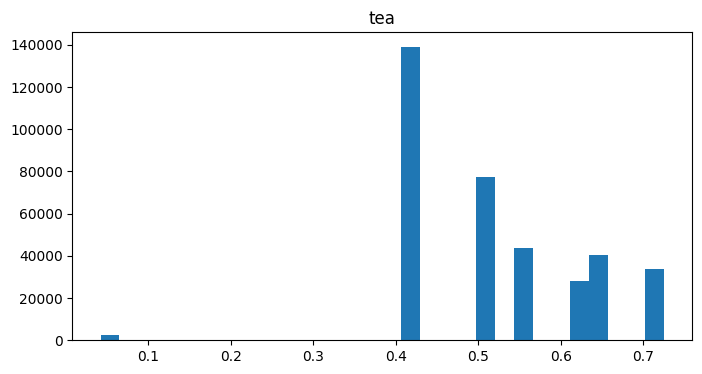

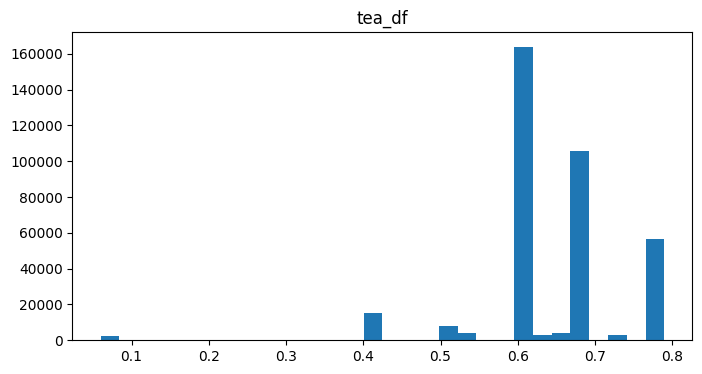

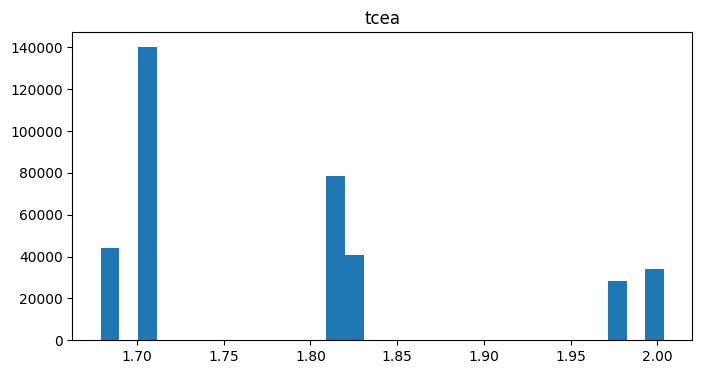

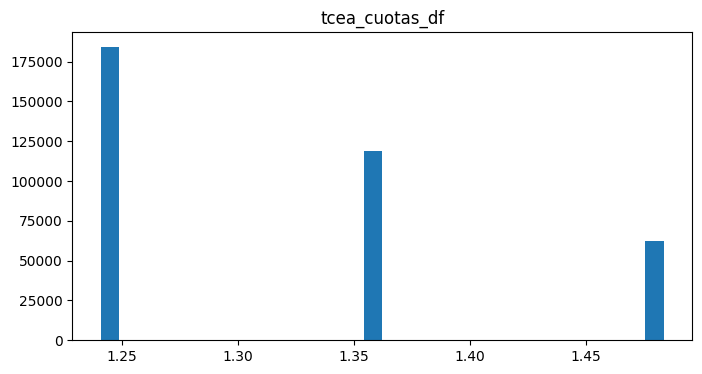

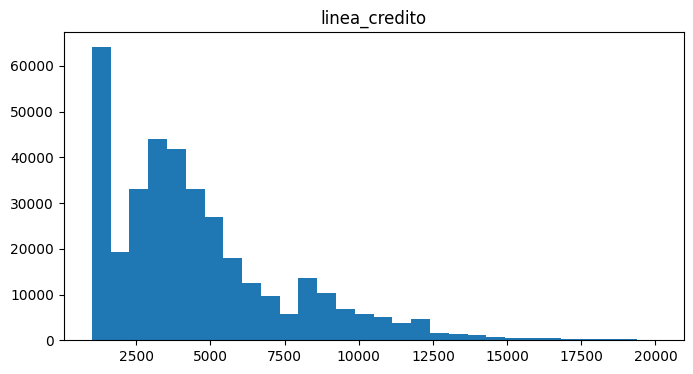

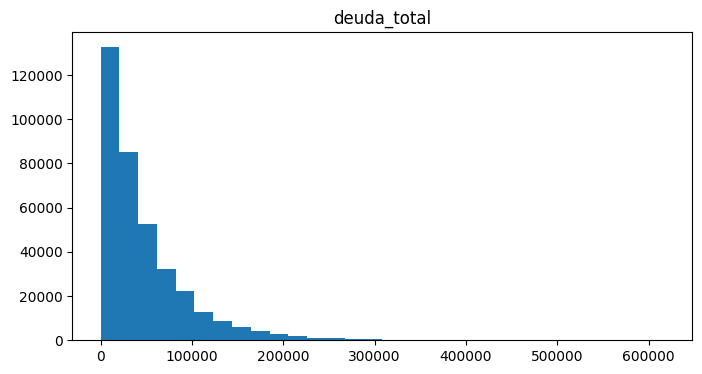

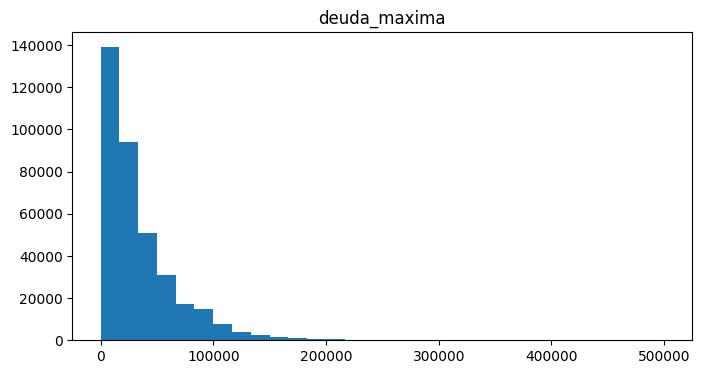

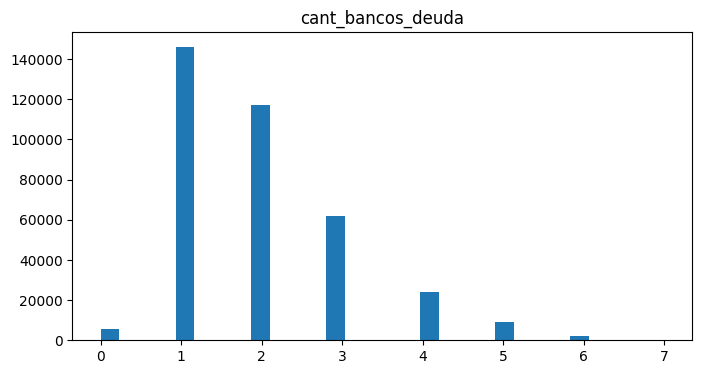

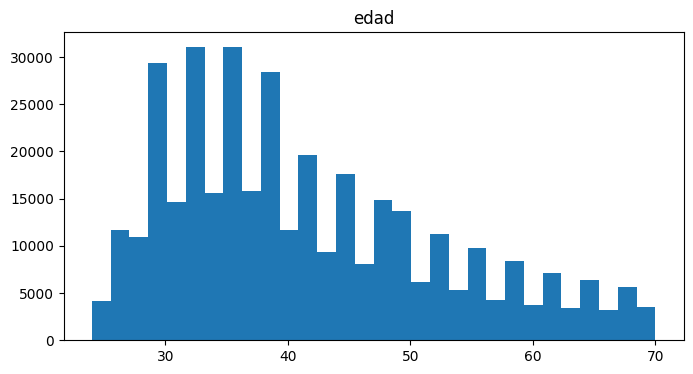

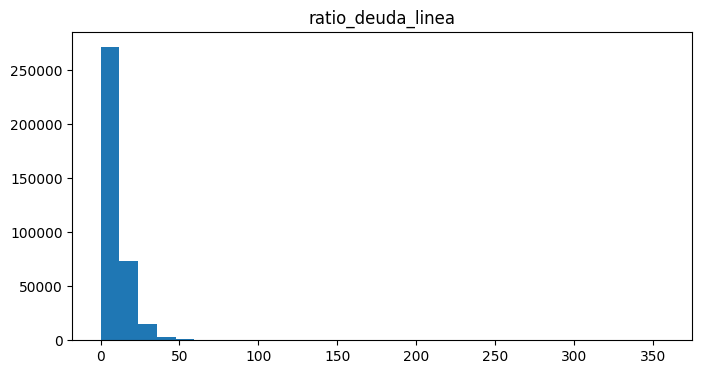

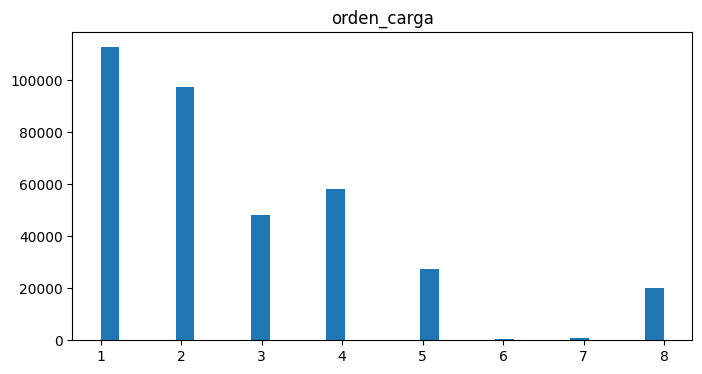

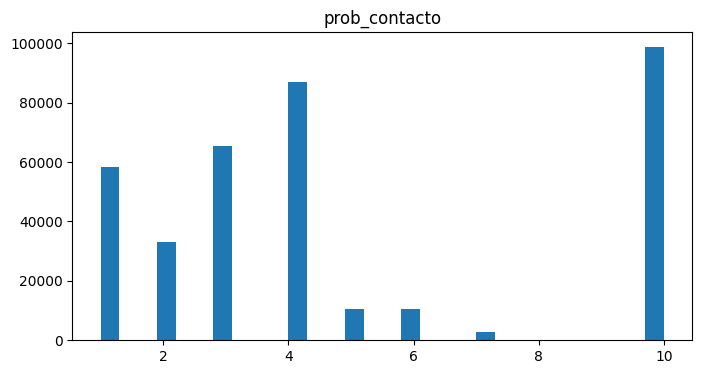

In [117]:
import matplotlib.pyplot as plt

for col in num_cols_01:

    plt.figure(figsize=(8,4))

    plt.hist(df_hist[col], bins=30)

    plt.title(col)

    plt.show()

<Figure size 800x400 with 0 Axes>

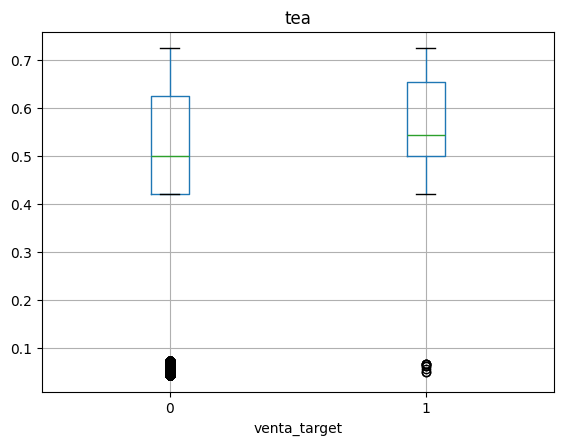

<Figure size 800x400 with 0 Axes>

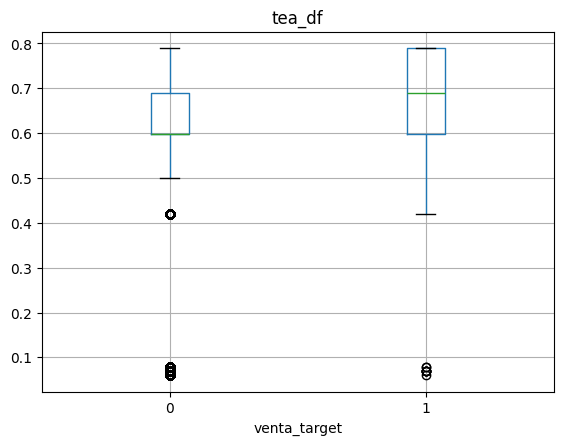

<Figure size 800x400 with 0 Axes>

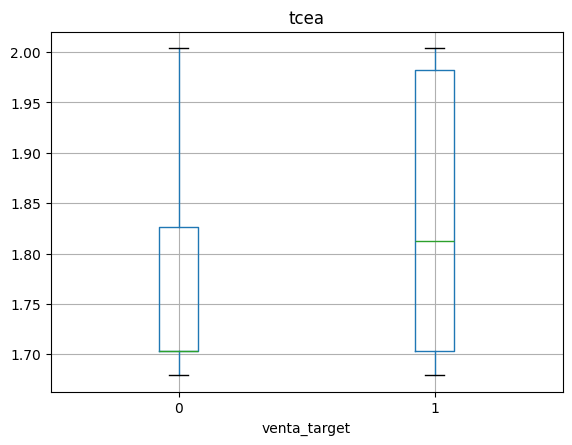

<Figure size 800x400 with 0 Axes>

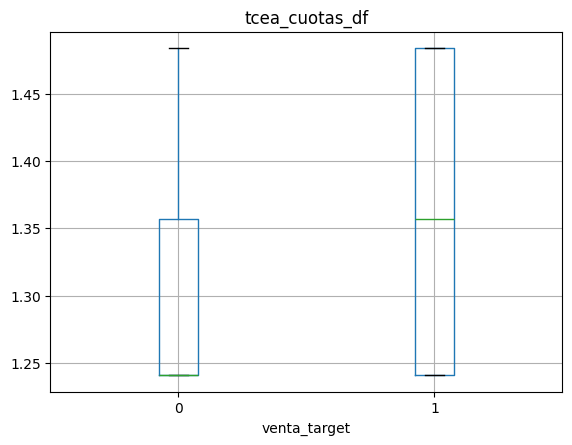

<Figure size 800x400 with 0 Axes>

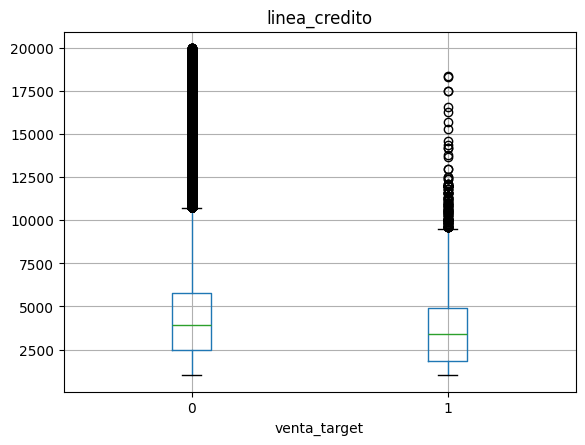

<Figure size 800x400 with 0 Axes>

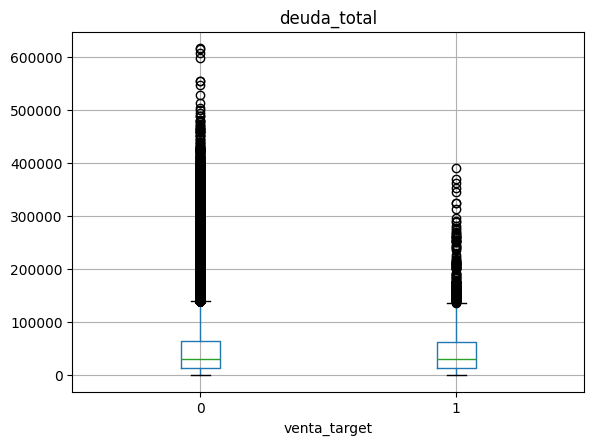

<Figure size 800x400 with 0 Axes>

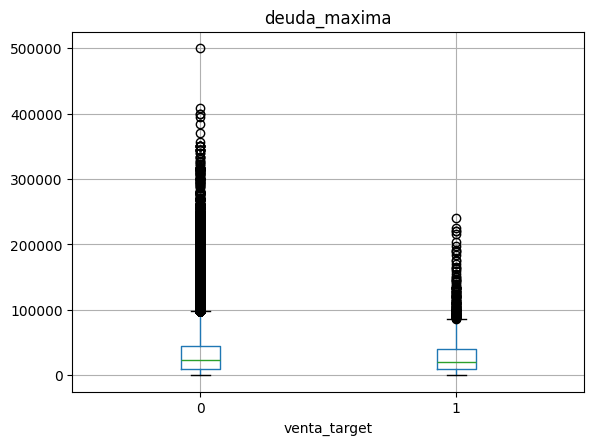

<Figure size 800x400 with 0 Axes>

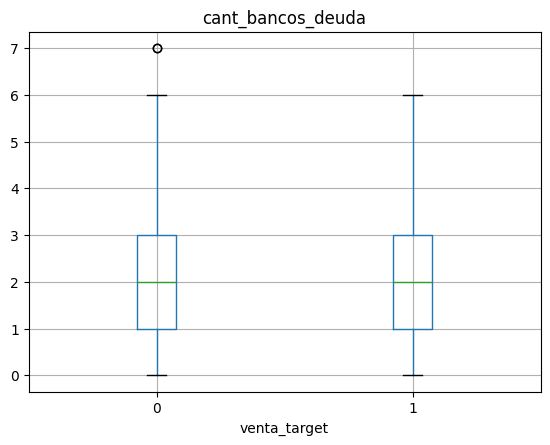

<Figure size 800x400 with 0 Axes>

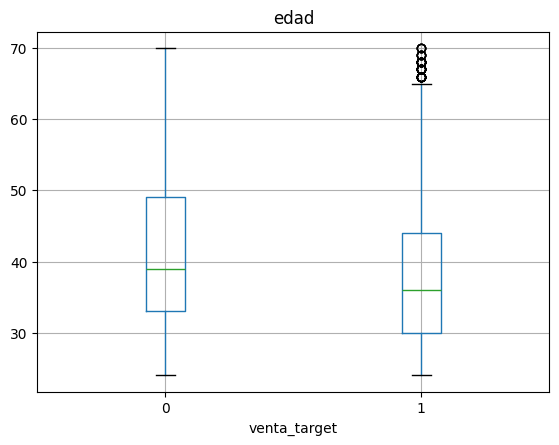

<Figure size 800x400 with 0 Axes>

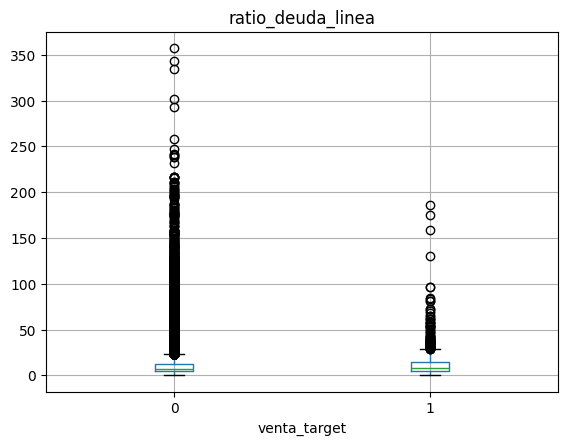

<Figure size 800x400 with 0 Axes>

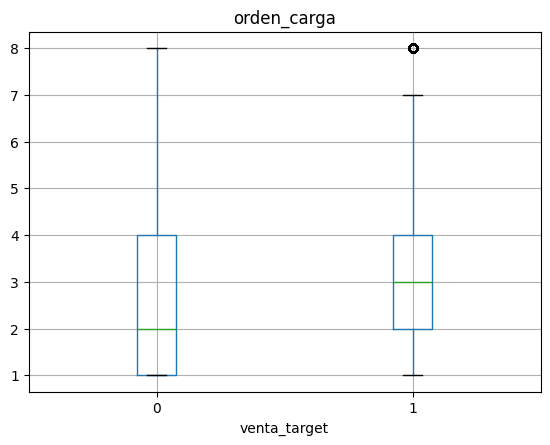

<Figure size 800x400 with 0 Axes>

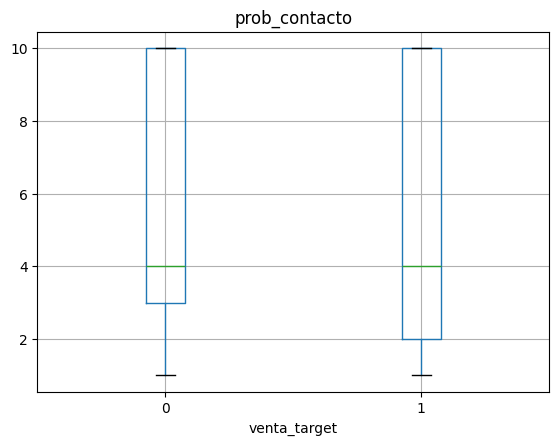

In [118]:
for col in num_cols_01:

    plt.figure(figsize=(8,4))

    df_hist.boxplot(
        column=col,
        by='venta_target'
    )

    plt.title(col)
    plt.suptitle('')

    plt.show()

In [119]:
df_hist['venta_target'].value_counts()

venta_target
0    363219
1      2518
Name: count, dtype: int64

In [ ]:
(
    df_hist['venta_target']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

venta_target
0    99.31
1     0.69
Name: proportion, dtype: float64

In [121]:
df_hist['venta_target'].value_counts()

venta_target
0    363219
1      2518
Name: count, dtype: int64

In [122]:
(
    df_hist
    .groupby('periodo')
    ['venta_target']
    .mean()
    .mul(100)
    .round(3)
)

periodo
2025-09    0.337
2025-10    0.502
2025-11    0.951
2025-12    0.533
2026-02    0.438
2026-03    0.887
2026-04    0.809
2026-05    1.444
2026-06    0.722
Name: venta_target, dtype: float64

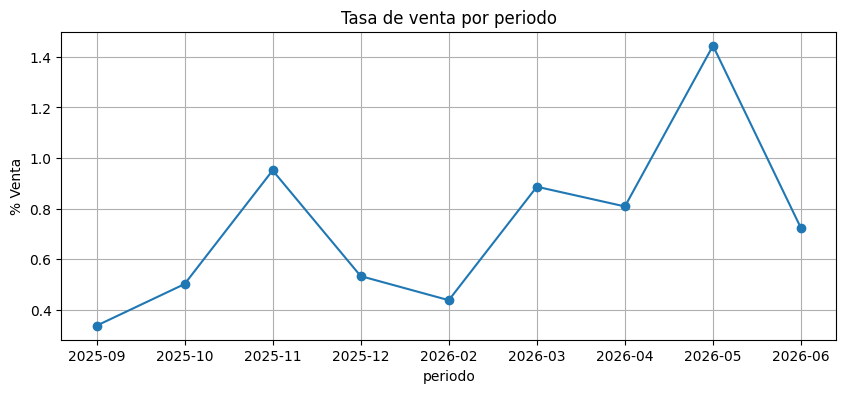

In [123]:
import matplotlib.pyplot as plt

tasa_mes = (
    df_hist
    .groupby('periodo')['venta_target']
    .mean()
    .mul(100)
)

tasa_mes.plot(marker='o', figsize=(10,4))
plt.ylabel('% Venta')
plt.title('Tasa de venta por periodo')
plt.grid(True)
plt.show()

In [107]:
resumen_nulos = pd.DataFrame({
    'nulos': df_hist.isnull().sum(),
    'pct_nulos': round(df_hist.isnull().mean()*100,2)
})

resumen_nulos.sort_values('pct_nulos', ascending=False)

,nulos,pct_nulos
vendor_lead_code,0,0.0
first_name,0,0.0
flg_promocion,0,0.0
tea,0,0.0
tea_df,0,0.0
tcea,0,0.0
tcea_cuotas_df,0,0.0
linea_credito,0,0.0
deuda_total,0,0.0
deuda_maxima,0,0.0


In [100]:
resumen_cat = pd.DataFrame({
    'categorias': df_hist.nunique(dropna=False)
})

resumen_cat.sort_values('categorias', ascending=False)

,categorias
vendor_lead_code,188396
ratio_deuda_linea,122303
deuda_total,66681
deuda_maxima,33697
duracion,1765
linea_credito,191
q_intentos,171
edad,47
dia_mes,32
n_base,22


In [76]:
for c in ['first_name','marca','n_base','seg_oferta']:

    print('\n',c)

    print(
        round(
            df_hist[c]
            .value_counts(normalize=True, dropna=False)
            *100,
            2
        )
        .head(10)
    )


 first_name
first_name
DCMSE    66.33
DCMA     33.67
Name: proportion, dtype: float64

 marca
marca
PERFIL SE    66.33
PERFIL DM    33.67
Name: proportion, dtype: float64

 n_base
n_base
SIN_DATO     61.96
Alpha        12.13
GRUPO BCH     7.33
Beta          5.46
GRUPO B       2.53
Alpha 2       2.27
Sigma         2.19
GRUPO A       1.95
Gamma         1.60
Pi            0.61
Name: proportion, dtype: float64

 seg_oferta
seg_oferta
A. 2,000 A 4000       32.98
B. 4,000 A 6,000      22.91
A. 1,000 A 2000       21.33
C. 6,000 A 8,000       8.48
D. 8,000 A 10,000      7.93
D. 10,000 A 12,000     4.29
E. 12,000 A MÁS        2.09
Name: proportion, dtype: float64


In [77]:
def evaluar_categorica(col):

    tmp = (
        df_hist
        .groupby(col, dropna=False)
        .agg(
            registros=('venta_target','count'),
            ventas=('venta_target','sum')
        )
    )

    tmp['pct_venta'] = round(
        tmp['ventas']*100/tmp['registros'],
        3
    )

    return tmp.sort_values(
        'pct_venta',
        ascending=False
    )

In [78]:
evaluar_categorica('first_name')

,registros,ventas,pct_venta
first_name,,,
DCMA,150241,1145,0.762
DCMSE,295956,1766,0.597


In [101]:
num_cols = [
    'edad',
    'linea_credito',
    'deuda_total',
    'deuda_maxima',
    'prob_contacto',
    'ratio_deuda_linea'
]

for c in num_cols:

    print('\n',c)

    print(
        df_hist
        .groupby('venta_target')[c]
        .mean()
    )


 edad
venta_target
0    41.502388
1    38.107228
Name: edad, dtype: float64

 linea_credito
venta_target
0    4558.773082
1    3941.064337
Name: linea_credito, dtype: object

 deuda_total
venta_target
0    47044.330729
1    48222.445592
Name: deuda_total, dtype: float64

 deuda_maxima
venta_target
0    33681.970376
1    30585.150516
Name: deuda_maxima, dtype: float64

 prob_contacto
venta_target
0    4.888541
1    5.229944
Name: prob_contacto, dtype: float64

 ratio_deuda_linea
venta_target
0     9.719744
1    11.610083
Name: ratio_deuda_linea, dtype: float64


In [81]:
resumen = pd.DataFrame({
    'tipo': df_hist.dtypes.astype(str),
    'nulos': df_hist.isnull().sum(),
    'pct_nulos': round(df_hist.isnull().mean()*100,2),
    'unicos': df_hist.nunique(dropna=False)
})

resumen

,tipo,nulos,pct_nulos,unicos
vendor_lead_code,object,0,0.0,196456
first_name,object,0,0.0,2
flg_promocion,int32,0,0.0,2
tea,object,0,0.0,18
tea_df,object,0,0.0,18
tcea,object,0,0.0,12
tcea_cuotas_df,object,0,0.0,7
linea_credito,object,0,0.0,191
deuda_total,float64,0,0.0,74654
deuda_maxima,float64,0,0.0,37102


In [102]:
import pandas as pd

pd.set_option('display.max_columns', None)

df_hist.head()

,vendor_lead_code,first_name,flg_promocion,tea,tea_df,tcea,tcea_cuotas_df,linea_credito,deuda_total,deuda_maxima,cant_bancos_deuda,marca,n_base,marca3,orden_carga,last_name,prob_contacto,edad,seg_edad,tramo,duracion,bench,periodo,anio,mes,grupo_tipificacion,dia_mes,dia_semana,ratio_deuda_linea,seg_oferta,seg_ratio_deuda,q_intentos,venta_target,flg_llamado
0,00239568,DCMSE,1,0.42000000,0.59900000,1.703,1.2407,4100.00,15000.0,15000.0,1,PERFIL SE,SIN_DATO,STOCK,1,LIMA,1,55,D. MADURO,17,0,l_bbva,2025-09,2025,9,CONTACTABILIDAD,26,6,3.658537,"B. 4,000 A 6,000",C. 300%-500%,1,0,1
1,00248242,DCMSE,1,0.62520000,0.78970000,1.982,1.4838,3600.00,36600.0,24000.0,3,PERFIL SE,SIN_DATO,STOCK,1,PROVINCIA,1,51,D. MADURO,11,0,l_bbva,2025-09,2025,9,SIN_GESTION,29,2,10.166667,"A. 2,000 A 4000",D. >500%,14,0,1
2,00369963,DCMSE,1,0.49970000,0.69000000,1.812,1.3568,6200.00,49200.0,49200.0,1,PERFIL SE,SIN_DATO,STOCK,1,LIMA,2,54,D. MADURO,13,0,l_bcp,2025-09,2025,9,CONTACTABILIDAD,25,5,7.935484,"C. 6,000 A 8,000",D. >500%,17,0,1
3,00435168,DCMSE,1,0.42000000,0.59900000,1.703,1.2407,7400.00,30172.0,30172.0,1,PERFIL SE,SIN_DATO,STOCK,1,LIMA,1,63,E. SENIOR,17,0,l_sco,2025-09,2025,9,CONTACTABILIDAD,29,2,4.077297,"C. 6,000 A 8,000",C. 300%-500%,14,0,1
4,00076301,DCMA,1,0.72530000,0.78970000,2.004,1.4838,2400.00,14038.0,8700.0,3,PERFIL DM,SIN_DATO,STOCK,1,PROVINCIA,1,56,E. SENIOR,16,0,l_bbva,2025-09,2025,9,CONTACTABILIDAD,26,6,5.849167,"A. 2,000 A 4000",D. >500%,3,0,1


In [69]:
for c in df_hist.columns:
    print(c)

vendor_lead_code
first_name
flg_promocion
tea
tea_df
tcea
tcea_cuotas_df
linea_credito
deuda_total
deuda_maxima
cant_bancos_deuda
marca
n_base
marca3
fecha_envio
orden_carga
last_name
prob_contacto
edad
seg_edad
tramo
fecha_llamada
duracion
bench
periodo
anio
mes
grupo_tipificacion
dia_mes
dia_semana
ratio_deuda_linea
seg_oferta
seg_ratio_deuda
q_intentos
venta_target
flg_llamado
grupo_prob


In [67]:
df_hist.head()

,vendor_lead_code,first_name,flg_promocion,tea,tea_df,tcea,tcea_cuotas_df,linea_credito,deuda_total,deuda_maxima,...,grupo_tipificacion,dia_mes,dia_semana,ratio_deuda_linea,seg_oferta,seg_ratio_deuda,q_intentos,venta_target,flg_llamado,grupo_prob
0,00119578,DCMSE,0,0.6252,0.7897,1.982,1.4838,4500.00,0.0,0.0,...,CONTACTABILIDAD,29,6,0.000,"B. 4,000 A 6,000",A. <=100%,11,0,1.0,"(0.999, 2.0]"
1,00219815,DCMA,0,0.7253,0.7897,2.004,1.4838,2400.00,0.0,0.0,...,CONTACTABILIDAD,29,6,0.000,"A. 2,000 A 4000",A. <=100%,10,0,1.0,"(0.999, 2.0]"
2,00003878,DCMA,0,0.7253,0.7897,2.004,1.4838,1000.00,1600.0,1600.0,...,CONTACTABILIDAD,29,6,1.600,"A. 1,000 A 2000",B. 100%-300%,10,0,1.0,"(0.999, 2.0]"
3,00082812,DCMA,0,0.7253,0.7897,2.004,1.4838,2200.00,0.0,0.0,...,CONTACTABILIDAD,29,6,0.000,"A. 2,000 A 4000",A. <=100%,9,0,1.0,"(0.999, 2.0]"
4,00091652,DCMSE,0,0.42,0.599,1.703,1.2407,3200.00,14000.0,12000.0,...,OBJECION_COMERCIAL,29,6,4.375,"A. 2,000 A 4000",C. 300%-500%,5,0,1.0,"(0.999, 2.0]"


In [ ]:

df_hist.groupby(['periodo']).size().reset_index(name='cantidad')

,periodo,cantidad
0,2025-08,35736
1,2025-09,41204
2,2025-10,47413
3,2025-11,22186
4,2025-12,47433
5,2026-01,44724
6,2026-02,64355
7,2026-03,49630
8,2026-04,37220
9,2026-05,34285


In [31]:
nulos = (
    df_hist
    .isnull()
    .sum()
    .reset_index()
)

nulos.columns = [
    'variable',
    'nulos'
]

nulos['pct'] = (
    nulos['nulos']
    / len(df_hist)
    * 100
).round(2)

nulos = (
    nulos[nulos['nulos'] > 0]
    .sort_values('pct', ascending=False)
)

nulos

,variable,nulos,pct


In [ ]:
(df_hist.groupby(['periodo', 'venta_target'])
        .size()
        .unstack(fill_value=0)
        .rename(columns={0: 'no_venta', 1: 'venta'}))

venta_target,no_venta,venta
periodo,,
2025-08,35591,145
2025-09,41065,139
2025-10,47175,238
2025-11,21975,211
2025-12,47180,253
2026-01,44469,255
2026-02,64073,282
2026-03,49190,440
2026-04,36919,301


## Base recorrida

In [ ]:
cat_cols = [
    'seg_oferta',
    'seg_ratio_deuda',
    'seg_edad',
    'tramo',
    'bench',
    'marca',
    'marca3'
]

for c in cat_cols:

    tmp = (
        df_hist
        .groupby(c, dropna=False)
        .agg(
            registros=('venta_target', 'count'),
            ventas=('venta_target', 'sum')
        )
        .assign(
            pct_venta=lambda x: round(x['ventas'] * 100 / x['registros'], 2)
        )
        .sort_values('pct_venta', ascending=False)
    )

    print('\n' + '=' * 60)
    print(c)
    print(tmp)

In [ ]:
['vendor_lead_code', 'first_name', 'flg_promocion', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', '', '', '', '', '', 'n_base', '', 'fecha_envio', 'orden_carga', 'last_name', '', '', '', '', 'fecha_llamada', 'duracion', '', 'periodo', 'anio', 'mes', 'grupo_tipificacion', 'dia_mes', 'dia_semana', '', '', '', 'q_intentos', 'venta_target', 'flg_llamado']

['vendor_lead_code', 'first_name', 'flg_promocion', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'deuda_total', 'deuda_maxima', 'cant_bancos_deuda', 'marca', 'n_base', 'marca3', 'fecha_envio', 'orden_carga', 'last_name', 'prob_contacto', 'edad', 'seg_edad', 'tramo', 'fecha_llamada', 'duracion', 'bench', 'periodo', 'anio', 'mes', 'grupo_tipificacion', 'dia_mes', 'dia_semana', 'ratio_deuda_linea', 'seg_oferta', 'seg_ratio_deuda', 'q_intentos', 'venta_target', 'flg_llamado']


In [ ]:
sin_gestion=['first_name','flg_promocion','tea','tea_df','tcea','tcea_cuotas_df','linea_credito','deuda_total','deuda_maxima','cant_bancos_deuda','marca','n_base','marca3','orden_carga','last_name','prob_contacto','edad','tramo','bench','ratio_deuda_linea','seg_oferta']
con_gestion=['flg_llamado','grupo_tipificacion','duracion']

In [62]:
tmp = (
    df_hist
    .groupby('n_base')
    .agg(
        registros=('venta_target','count'),
        ventas=('venta_target','sum')
    )
)

tmp['pct_venta'] = (
    tmp['ventas'] / tmp['registros'] * 100
)

tmp = tmp[tmp['registros'] >= 1000]

tmp.sort_values('pct_venta', ascending=False)

,registros,ventas,pct_venta
n_base,,,
Pi,2700,56,2.074074
Sigma,9757,167,1.711592
GRUPO A,8693,113,1.299896
Alpha 2,10110,129,1.275964
Gamma,7148,77,1.077224
Beta,24376,183,0.750738
GrupoB.2,2087,15,0.718735
Alpha,54107,356,0.657956
SIN_DATO,276459,1580,0.571513


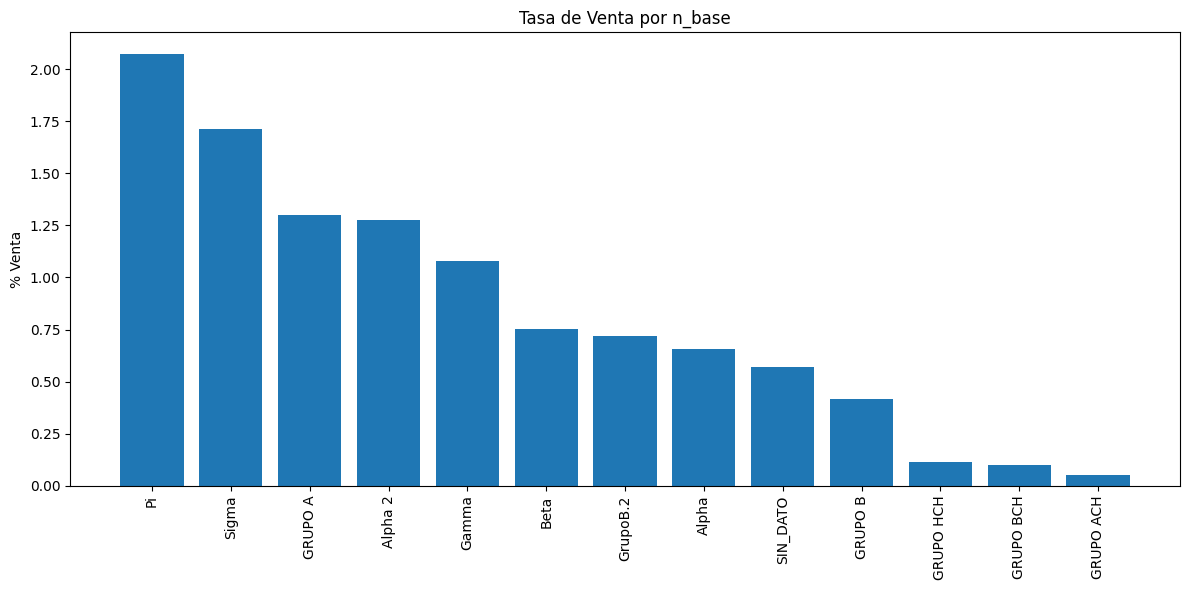

In [65]:
import matplotlib.pyplot as plt

tmp = tmp.sort_values('pct_venta', ascending=False)

plt.figure(figsize=(12,6))
plt.bar(tmp.index.astype(str), tmp['pct_venta'])
plt.xticks(rotation=90)
plt.ylabel('% Venta')
plt.title('Tasa de Venta por n_base')
plt.tight_layout()
plt.show()

In [66]:
import pandas as pd

df_hist['grupo_prob'] = pd.qcut(
    df_hist['prob_contacto'],
    10,
    duplicates='drop'
)

tmp = (
    df_hist
    .groupby('grupo_prob')
    .agg(
        registros=('venta_target','count'),
        ventas=('venta_target','sum')
    )
)

tmp['pct_venta'] = (
    tmp['ventas']/tmp['registros']*100
)

tmp

C:\Users\DATA\AppData\Local\Temp\ipykernel_1420\3628347017.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('grupo_prob')


,registros,ventas,pct_venta
grupo_prob,,,
"(0.999, 2.0]",146839,1091,0.742991
"(2.0, 3.0]",73832,473,0.640644
"(3.0, 4.0]",93488,308,0.329454
"(4.0, 10.0]",132038,1039,0.786895


In [61]:
for c in [
    'first_name',
    'flg_promocion',
    'n_base',
    'marca',
    'seg_oferta',
    'last_name'
]:

    tmp = (
        df_hist
        .groupby(c)
        .agg(
            registros=('venta_target','count'),
            ventas=('venta_target','sum')
        )
    )

    tmp['pct_venta'] = (
        tmp['ventas'] /
        tmp['registros'] * 100
    )

    print("\n",c)
    print(tmp.sort_values('pct_venta',ascending=False))


 first_name
            registros  ventas  pct_venta
first_name                              
DCMA           150241    1145   0.762109
DCMSE          295956    1766   0.596710

 flg_promocion
               registros  ventas  pct_venta
flg_promocion                              
0                 249390    1703   0.682866
1                 196807    1208   0.613799

 n_base
           registros  ventas   pct_venta
n_base                                  
Delta             78      78  100.000000
TARGET_R           1       1  100.000000
TARGET             2       1   50.000000
GRUPO E           72       6    8.333333
pi               149       9    6.040268
GRUPO D          235      11    4.680851
GRUPO C.2        574      25    4.355401
Zeta             664      14    2.108434
Pi              2700      56    2.074074
GRUPO C          375       7    1.866667
Sigma           9757     167    1.711592
GRUPO A         8693     113    1.299896
Alpha 2        10110     129    1.275964
Gamma  

In [ ]:
num_cols = [
    'edad',
    'linea_credito',
    'deuda_total',
    'deuda_maxima',
    'cant_bancos_deuda',
    'prob_contacto',
    'ratio_deuda_linea'
]

for c in num_cols:

    print('\n' + '=' * 60)
    print(c)

    print(
        df_hist
        .groupby('venta_target')[c]
        .mean()
        .round(2)
    )

In [24]:
print(df_hist.columns.tolist())

['vendor_lead_code', 'first_name', 'flg_promocion', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'deuda_total', 'deuda_maxima', 'cant_bancos_deuda', 'marca', 'n_base', 'marca3', 'fecha_envio', 'orden_carga', 'last_name', 'prob_contacto', 'edad', 'seg_edad', 'tramo', 'duracion', 'bench', 'periodo', 'anio', 'mes', 'grupo_tipificacion', 'dia_mes', 'dia_semana', 'ratio_deuda_linea', 'seg_oferta', 'seg_ratio_deuda', 'venta_target', 'flg_llamado']


In [25]:
print(
    df_hist['first_name']
    .drop_duplicates()
    .tolist()
)

['DCMA', 'DCMSE']


In [ ]:
fecha_mes_base='2026-05-01'
ruta_parquet = os.path.join(ruta_csv, 'dataset_credicash_ml.parquet')

credicash_carga_modelo(spark,fecha_mes_base)

periodo_actual = pd.to_datetime(fecha_mes_base).strftime("%Y%m")
print("Periodo en proceso:", periodo_actual)
df_modelo = tb_ml_proceso_spark()
df = tb_ml_imputacion_py(df_modelo)
df_hist = add_dataset_ml(df, ruta_parquet, periodo_actual)


In [94]:
print(df_modelo.columns)

['vendor_lead_code', 'first_name', 'flg_promocion', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'deuda_total', 'deuda_maxima', 'cant_bancos_deuda', 'marca', 'n_base', 'marca3', 'fecha_envio', 'orden_carga', 'last_name', 'prob_contacto', 'edad', 'seg_edad', 'tramo', 'fecha_llamada', 'duracion', 'bench', 'periodo', 'anio', 'mes', 'grupo_tipificacion', 'dia_mes', 'dia_semana', 'ratio_deuda_linea', 'seg_oferta', 'seg_ratio_deuda', 'venta_target']


In [102]:
df_modelo.select(
    'vendor_lead_code',
     'first_name',
     'flg_promocion',
     'tea',
     'tea_df',
     'tcea',
     'tcea_cuotas_df',
     'linea_credito',
     'deuda_total',
     'deuda_maxima',
     'cant_bancos_deuda',
     'marca',
     'n_base',
     'marca3',
     'fecha_envio',
     'orden_carga',
     'last_name',
     'prob_contacto'
).show()

{"ts": "2026-06-07 23:02:56.777", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[CAST_INVALID_INPUT] The value '' of the type \"STRING\" cannot be cast to \"INT\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018", "context": {"file": "line 14 in cell [86]", "line": "", "fragment": "cast", "errorClass": "CAST_INVALID_INPUT"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o13512.showString.\n: org.apache.spark.SparkNumberFormatException: [CAST_INVALID_INPUT] The value '' of the type \"STRING\" cannot be cast to \"INT\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018\n== DataFrame ==\n\"cast\" was called from\nline 14 in cell [86]\n\r\n\tat org.apache.spark.sql.errors.QueryExecutionErrors$.

NumberFormatException: [CAST_INVALID_INPUT] The value '' of the type "STRING" cannot be cast to "INT" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"cast" was called from
line 14 in cell [86]


In [93]:
df_modelo.show(5)

{"ts": "2026-06-07 22:58:16.869", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[CAST_INVALID_INPUT] The value '' of the type \"STRING\" cannot be cast to \"INT\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018", "context": {"file": "line 14 in cell [86]", "line": "", "fragment": "cast", "errorClass": "CAST_INVALID_INPUT"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o13004.showString.\n: org.apache.spark.SparkNumberFormatException: [CAST_INVALID_INPUT] The value '' of the type \"STRING\" cannot be cast to \"INT\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018\n== DataFrame ==\n\"cast\" was called from\nline 14 in cell [86]\n\r\n\tat org.apache.spark.sql.errors.QueryExecutionErrors$.

NumberFormatException: [CAST_INVALID_INPUT] The value '' of the type "STRING" cannot be cast to "INT" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"cast" was called from
line 14 in cell [86]


In [92]:
total = df_modelo.count()

df_nulos = df_modelo.select([
    F.sum(
        F.when(F.col(c).isNull(), 1).otherwise(0)
    ).alias(c)
    for c in df_modelo.columns
])

# Convertimos solo el resumen a pandas
pdf_nulos = df_nulos.toPandas().T.reset_index()

pdf_nulos.columns = ["columna", "nulos"]

pdf_nulos["pct_nulos"] = round(
    pdf_nulos["nulos"] * 100 / total,
    2
)

# Solo columnas con nulos
pdf_nulos = pdf_nulos[
    pdf_nulos["nulos"] > 0
].sort_values(
    "pct_nulos",
    ascending=False
)

print(pdf_nulos)

{"ts": "2026-06-07 22:57:47.126", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[CAST_INVALID_INPUT] The value '' of the type \"STRING\" cannot be cast to \"INT\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018", "context": {"file": "line 14 in cell [86]", "line": "", "fragment": "cast", "errorClass": "CAST_INVALID_INPUT"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o13359.collectToPython.\n: org.apache.spark.SparkNumberFormatException: [CAST_INVALID_INPUT] The value '' of the type \"STRING\" cannot be cast to \"INT\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018\n== DataFrame ==\n\"cast\" was called from\nline 14 in cell [86]\n\r\n\tat org.apache.spark.sql.errors.QueryExecutionErr

NumberFormatException: [CAST_INVALID_INPUT] The value '' of the type "STRING" cannot be cast to "INT" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"cast" was called from
line 14 in cell [86]


In [90]:
from pyspark.sql import functions as F

cols_int = [
    "flg_promocion",
    "orden_carga",
    "prob_contacto",
    "edad",
    "tramo",
    "duracion",
    "anio",
    "mes",
    "dia_mes",
    "dia_semana"
]

for c in cols_int:
    df_modelo = df_modelo.withColumn(
        c,
        F.expr(f"try_cast(NULLIF(TRIM(CAST(`{c}` AS STRING)), '') AS INT)")
    )

df_modelo = df_modelo.withColumn(
    "venta_target",
    F.when(F.col("venta_target") == 1, F.lit(1)).otherwise(F.lit(0)).cast("int")
)

In [91]:
df_modelo.show()

{"ts": "2026-06-07 22:57:32.777", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[CAST_INVALID_INPUT] The value '' of the type \"STRING\" cannot be cast to \"INT\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018", "context": {"file": "line 14 in cell [86]", "line": "", "fragment": "cast", "errorClass": "CAST_INVALID_INPUT"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o13004.showString.\n: org.apache.spark.SparkNumberFormatException: [CAST_INVALID_INPUT] The value '' of the type \"STRING\" cannot be cast to \"INT\" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018\n== DataFrame ==\n\"cast\" was called from\nline 14 in cell [86]\n\r\n\tat org.apache.spark.sql.errors.QueryExecutionErrors$.

NumberFormatException: [CAST_INVALID_INPUT] The value '' of the type "STRING" cannot be cast to "INT" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"cast" was called from
line 14 in cell [86]


In [68]:
columnas_num = [
    'tea',
    'tcea',
    'tcea_cuotas_df',
    'linea_credito',
    'deuda_total',
    'deuda_maxima',
    'cant_bancos_deuda',
    'edad',
    'duracion',
    'ratio_deuda_linea'
]

df_modelo.select([
    F.min(c).alias(f'{c}_min')
    for c in columnas_num
] + [
    F.max(c).alias(f'{c}_max')
    for c in columnas_num
]).show(vertical=True, truncate=False)

-RECORD 0-----------------------------------
 tea_min               | 0.42               
 tcea_min              | 1.679              
 tcea_cuotas_df_min    | 1.2407             
 linea_credito_min     | 625.00             
 deuda_total_min       | 0.0                
 deuda_maxima_min      | 0.0                
 cant_bancos_deuda_min | 0                  
 edad_min              | 24                 
 duracion_min          | 0                  
 ratio_deuda_linea_min | 0.0                
 tea_max               | 0.72530000         
 tcea_max              | 2.004              
 tcea_cuotas_df_max    | 1.4838             
 linea_credito_max     | 20000.00           
 deuda_total_max       | 494534.0           
 deuda_maxima_max      | 313902.0           
 cant_bancos_deuda_max | 6                  
 edad_max              | 70                 
 duracion_max          | 3988               
 ratio_deuda_linea_max | 176.12615384615384 



In [69]:
df_modelo.select(columnas_num).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
).show(truncate=False)

+-------+-------------------+-------------------+-------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+
|summary|tea                |tcea               |tcea_cuotas_df     |linea_credito     |deuda_total      |deuda_maxima      |cant_bancos_deuda |edad              |duracion          |ratio_deuda_linea |
+-------+-------------------+-------------------+-------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+
|count  |34672              |34672              |34671              |34672             |34672            |34672             |34672             |34672             |34672             |34672             |
|mean   |0.5408621567835341 |1.808690712967566  |1.3383449511124812 |4140.387777       |41258.42699786571|29381.13956131749 |1.9311836640516844|39.206131748961695|45.88131633594831 |9.29058654

In [79]:
total = df_modelo.count()

df_modelo.groupBy("venta_target").count()\
    .withColumn(
        "pct",
        F.round(F.col("count") * 100 / total, 2)
    ).show()

+------------+-----+-----+
|venta_target|count|  pct|
+------------+-----+-----+
|           1|  496| 1.45|
|           0|33790|98.55|
+------------+-----+-----+



In [47]:
print([row['tea' ] for row in df_modelo.select('tea').distinct().collect()])


['42', '0.6252', '62.52', '72.53', '0.7253', '0.42', '0.6554', '0.5447', '49.97', '0.4997', '54.47', '65.54']


In [30]:
total = df_modelo.count()

df_modelo.groupBy("venta_target").count()\
    .withColumn(
        "pct",
        F.round(F.col("count") * 100 / total, 2)
    ).show()

+------------+-----+-----+
|venta_target|count|  pct|
+------------+-----+-----+
|        NULL|33790|98.55|
|           1|  496| 1.45|
+------------+-----+-----+



In [34]:
df_modelo.show()

+----------------+----------+-------------+------+------+--------------+-------------+-----------+------------+-----------------+---------+------+------+-----------+-----------+---------+-------------+----+---------------+-----+-------------+--------+------+-------+----+---+-------------------+-------+----------+------------------+---------------+------------+
|vendor_lead_code|first_name|flg_promocion|   tea|  tcea|tcea_cuotas_df|linea_credito|deuda_total|deuda_maxima|cant_bancos_deuda|    marca|n_base|marca3|fecha_envio|orden_carga|last_name|prob_contacto|edad|       seg_edad|tramo|fecha_llamada|duracion| bench|periodo|anio|mes| grupo_tipificacion|dia_mes|dia_semana| ratio_deuda_linea|seg_ratio_deuda|venta_target|
+----------------+----------+-------------+------+------+--------------+-------------+-----------+------------+-----------------+---------+------+------+-----------+-----------+---------+-------------+----+---------------+-----+-------------+--------+------+-------+----+---

In [32]:
pdf = df_modelo.toPandas()

<Axes: >

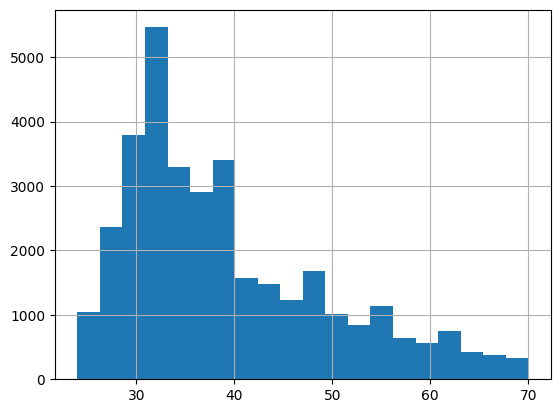

In [33]:
pdf["edad"].hist(bins=20)

In [31]:
df_modelo.groupBy("edad").count().orderBy("edad").show()

+----+-----+
|edad|count|
+----+-----+
|  24|  135|
|  25|  375|
|  26|  540|
|  27|  749|
|  28| 1616|
|  29| 1900|
|  30| 1892|
|  31| 1872|
|  32| 1814|
|  33| 1777|
|  34| 1637|
|  35| 1660|
|  36| 1520|
|  37| 1383|
|  38| 1292|
|  39| 1115|
|  40|  998|
|  41|  822|
|  42|  748|
|  43|  744|
+----+-----+
only showing top 20 rows


In [ ]:
http://192.168.2.100/Cronox

In [22]:
df_list.groupBy("retiro","venta_target").count().show()

+---------+------------+-----+
|   retiro|venta_target|count|
+---------+------------+-----+
|no_aplica|        NULL|33790|
|no_aplica|           1|  496|
|   retiro|        NULL|  386|
+---------+------------+-----+



In [35]:
query = f"""
SELECT Dni as vendor_lead_code,  fecha_hora_llamada, segundos as duracion, Trama_Hora as tramo, phone_number, Descripcion_ as mejor_descripcion
FROM MAEBA.ADM_OBJ_TG.synTmpLLamadasDinersTc
WHERE CONVERT(DATE, Fecha_Hora_Llamada) >= CONVERT(DATE, '{fecha_mes_base}')
  AND CONVERT(DATE, Fecha_Hora_Llamada) < DATEADD(MONTH, 1, CONVERT(DATE, '{fecha_mes_base}'))
"""
df_mejor_tipi = obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
df_mejor_tipi.show(4)


+----------------+-------------------+--------+-----+------------+-----------------+
|vendor_lead_code| fecha_hora_llamada|duracion|tramo|phone_number|mejor_descripcion|
+----------------+-------------------+--------+-----+------------+-----------------+
|        09998461|2026-06-04 15:22:59|       0|   15|   949056522| TELEFONO APAGADO|
|        10000420|2026-06-04 09:35:40|       0|    9|   995732518| TELEFONO APAGADO|
|        10005152|2026-06-04 16:22:38|       0|   16|   931264376|   LINEA SATURADA|
|        10009648|2026-06-04 15:37:41|       0|   15|   929464689| TELEFONO APAGADO|
+----------------+-------------------+--------+-----+------------+-----------------+
only showing top 4 rows


In [34]:

'Dni',  'Fecha_Hora_Llamada', 'segundos', 'Fecha_Llamada', 'Trama_Hora', 'PHONE_NUMBER', 'Descripcion_'
df_mejor_tipi.select(
).show(4)
    

+--------+-------------------+--------+-------------+----------+------------+----------------+
|     Dni| Fecha_Hora_Llamada|segundos|Fecha_Llamada|Trama_Hora|PHONE_NUMBER|    Descripcion_|
+--------+-------------------+--------+-------------+----------+------------+----------------+
|09998461|2026-06-04 15:22:59|       0|   2026-06-04|        15|   949056522|TELEFONO APAGADO|
|10000420|2026-06-04 09:35:40|       0|   2026-06-04|         9|   995732518|TELEFONO APAGADO|
|10005152|2026-06-04 16:22:38|       0|   2026-06-04|        16|   931264376|  LINEA SATURADA|
|10009648|2026-06-04 15:37:41|       0|   2026-06-04|        15|   929464689|TELEFONO APAGADO|
+--------+-------------------+--------+-------------+----------+------------+----------------+
only showing top 4 rows


In [22]:
query = """
SELECT TOP 5 *
FROM MAEBA.ADM_OBJ_TG.synTmpLLamadasDinersTc
"""

df_test = obtener_tabla_sql(
    spark, query, server_zeus, user_zeus, pwd_zeus, "MAEBA"
)

df_test.show(truncate=False)
df_test.printSchema()

+---------------+--------------+--------+--------------+-----------------+-------------+------------------+-------------------+--------+-------------+----------+-------+----------+----------------------+----------------+---------------+------------+------------+-----------+-------------+-------------------+-------------------+-------+-----------+---------------+----------------+-----+------------------+----------+------------+---+-------+------+----+
|Mejor_Resultado|Mejor_Telefono|Dni     |Numero_Campana|Nombre_Campana   |DNI_Ejecutivo|Ejecutivo         |Fecha_Hora_Llamada |segundos|Fecha_Llamada|Trama_Hora|Estados|Sub_estado|Descripcion           |list_description|list_name      |PHONE_NUMBER|Fecha_Agenda|Comentarios|Codigo_Paleta|Inicio             |Fin                |lead_id|Estado_    |Sub_Estado_    |Descripcion_    |Pesos|Enlace            |Fecha_Llam|Hora_Llamada|RH |COD_BCO|COMENT|RHFC|
+---------------+--------------+--------+--------------+-----------------+-------------+--

In [19]:
fecha_mes_base='2026-06-01'

In [20]:
df_mejor_tipi.show(3)

+---------------+--------------+---+--------------+--------------+-------------+---------+------------------+--------+-------------+----------+-------+----------+-----------+----------------+---------+------------+------------+-----------+-------------+------+---+-------+-------+-----------+------------+-----+------+----------+------------+---+-------+------+----+
|Mejor_Resultado|Mejor_Telefono|Dni|Numero_Campana|Nombre_Campana|DNI_Ejecutivo|Ejecutivo|Fecha_Hora_Llamada|segundos|Fecha_Llamada|Trama_Hora|Estados|Sub_estado|Descripcion|list_description|list_name|PHONE_NUMBER|Fecha_Agenda|Comentarios|Codigo_Paleta|Inicio|Fin|lead_id|Estado_|Sub_Estado_|Descripcion_|Pesos|Enlace|Fecha_Llam|Hora_Llamada| RH|COD_BCO|COMENT|RHFC|
+---------------+--------------+---+--------------+--------------+-------------+---------+------------------+--------+-------------+----------+-------+----------+-----------+----------------+---------+------------+------------+-----------+-------------+------+---+--

In [ ]:


# df_list=df_list.drop('provincia')
# df_list=df_list.withColumnRenamed('marca','perfil')
# df_list=df_list.withColumnRenamed('marca3','recencia')
# df_list=df_list.withColumnRenamed('last_name','provincia')

In [ ]:
# Crear el diagrama de dispersión
plt.scatter(df['Edad'], df['Salario'], color='blue', marker='o')
plt.title('Relación entre Edad y Salario')
plt.xlabel('Edad')
plt.ylabel('Salario')
plt.grid(True)

In [41]:
df_venta=df_venta.select('vendor_lead_code',F.lit(1).alias('venta_target'))

['fecha_gestion',
 'vendor_lead_code',
 'promotor',
 'estado_venta',
 'tramo_venta',
 'monto_venta',
 'dni_ejecutivo_venta',
 'producto_venta',
 'title',
 'cel_venta',
 'venta',
 'subcampana']

['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_codigo_cli', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'mejor_codigo_telf', 'q_intentos_telf', 'q_intentos_dia', 'duracion', 'dni_unico', 'mejor_estado_tipi_cli

In [ ]:
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_codigo_cli', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'mejor_codigo_telf', 'q_intentos_telf', 'q_intentos_dia', 'duracion', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli']

In [8]:
print([row['mejor_descripcion_cli' ] for row in df_list.select('mejor_descripcion_cli').distinct().collect()])


['MALA EXPERIENCIA', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL (SEGURO)', 'POR SEGURO DE DESGRAVAMEN ', 'POR LINEA DE CREDITO', 'TASA DE INTERES ALTA', 'FALLECIO', 'VENTA POR OTRO CANAL', 'AGENTE NO DISPONIBLE ', 'DESEA EFECTIVO  - TIENE UN PRESTAMO', 'NO TIENE ACEPTACION', 'CLIENTE ACEPTO OFERTA TC SIN TRANSFERIR', 'NO TIPIFICO A TIEMPO', 'AGENDA', 'CLIENTE NO ESCUCHA OFERTA', 'TELEF. FUERA DE SERVICIO', 'LINEA SATURADA', 'TELEFONO APAGADO', 'POR MEMBRESÍA', 'NO CALIFICA ENTREGA', 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA', 'CLIENTE ACEPTO OFERTA TC (SEGURO)', 'CLIENTE DESEA QUE NO VUELVAN A LLAMAR', 'CONTACTO CON TERCERO (CONOCE AL TITULAR)', 'ACEPTA ENVIO WHATSAPP', 'OCUPADO', 'TELEF. NO EXISTE', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL  SIN TRANSFERIR', 'NO CALIFICA COMERCIAL', 'PROGRAMA DE RECOMPENSAS', 'NO RECONOCE LA MARCA', 'CLIENTE CORTO SIN ESCUCHAR OFERTA', 'CONTACTO CON TERCERO ( NO CONOCE AL TITULAR)', 'SE ENCUENTRA DE VIAJE', 'NO CONFIA EN VENTA TELEFONICA', 'CLIENTE NO ESCUCHA 

In [ ]:

# def tb_ml_proceso_spark():

relanzable = [ 'POR SEGURO DE DESGRAVAMEN ', 'POR LINEA DE CREDITO', 'TASA DE INTERES ALTA',   'AGENTE NO DISPONIBLE ',    'NO TIPIFICO A TIEMPO', 'CLIENTE NO ESCUCHA OFERTA',  'LINEA SATURADA', 'TELEFONO APAGADO', 'POR MEMBRESÍA',  'CONTACTO CON TERCERO (CONOCE AL TITULAR)', 'ACEPTA ENVIO WHATSAPP', 'OCUPADO',  'PROGRAMA DE RECOMPENSAS',  'CLIENTE CORTO SIN ESCUCHAR OFERTA',   'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPADO', 'CLIENTE NO ESCUCHA OFERTA - ACEPTA WHATSAPP', 'LLAMADA CORTADA/ERROR DE COMUNICACION', 'NO CONTESTA', 'PREFIERE SU PROPIO BANCO', 'TITULAR DESEA QUE VUELVAN A LLAMAR', 'NO DESEA DAR MOTIVOS', ]

relanzable_poco_uso = [
    'MALA EXPERIENCIA', 
 'NO CONFIA EN VENTA TELEFONICA',
'CONTACTO CON TERCERO ( NO CONOCE AL TITULAR)',
'SE ENCUENTRA DE VIAJE',
'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA', 
'NO RECONOCE LA MARCA',
'AGENDA', 
]

no_relanzable=[
    'VENTA POR OTRO CANAL',
    'FALLECIO',
    'DESEA EFECTIVO  - TIENE UN PRESTAMO',
    'NO TIENE ACEPTACION',
    'TELEF. NO EXISTE',
    'NO CALIFICA COMERCIAL',
    'CLIENTE DESEA QUE NO VUELVAN A LLAMAR', 
     'NO CALIFICA ENTREGA',
     'CLIENTE ACEPTO OFERTA TC (SEGURO)',
     'CLIENTE ACEPTO OFERTA TC + ADICIONAL (SEGURO)',
     'CLIENTE ACEPTO OFERTA TC SIN TRANSFERIR',
     'TELEF. FUERA DE SERVICIO',
     'CLIENTE ACEPTO OFERTA TC + ADICIONAL  SIN TRANSFERIR',
    ]   

query = """
SELECT * FROM cronox.dbo.borrar_credicash_01
    """
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

df_list=df_list.withColumn('oferta_electro',F.when((F.col('oferta_electro').isNull())&(F.col('oferta_electro').isNull()),F.col('oferta_max'))
                                            .otherwise(F.col('oferta_electro'))
                            )
df_list=df_list.withColumn('tasa_credicash',F.when((F.col('tasa_credicash').isNull())&(F.col('tasa_electro').isNull()),F.col('tasa'))
                                            .otherwise(F.col('tasa_credicash'))
                            )

df_list=df_list.withColumn('lote_01',F.when(F.col('lote')=='REINGRESO',F.lit('04.BASE REGULAR'))
    .when(F.col('frescura')=='0','02. FRESCURA CERO')
    .when(F.col('grupo_segmento')=='R',F.lit('03.BASE CLIENTE'))
    .when(F.col('lote')=='INVENTARIO','01.INVENTARIO')
    .otherwise(F.lit('04.BASE REGULAR'))
)

window_part = Window.partitionBy("dni_cliente")

df_list = (
    df_list
    .withColumn(
        "flg_contacto_positivo",
        F.when(F.col("mejor15_estado_tipi_cli").isin(*cet_positivo), 1).otherwise(0)
    )
    .withColumn(
        "flg_contacto_negativo",
        F.when(F.col("mejor15_estado_tipi_cli").isin(*cet_negativo), 1).otherwise(0)
    )
    .withColumn(
        "flg_no_contacto",
        F.when(F.col("mejor15_estado_tipi_cli").isin(*no_cet), 1).otherwise(0)
    )
    .withColumn(
        "q_contacto_positivo",
        F.sum("flg_contacto_positivo").over(window_part)
    )
    .withColumn(
        "q_contacto_negativo",
        F.sum("flg_contacto_negativo").over(window_part)
    )
    .withColumn(
        "q_no_contacto",
        F.sum("flg_no_contacto").over(window_part)
    )
)

df_list = (
    df_list
    .withColumn("cl_carga", F.to_date("cl_carga"))
    .withColumn("anio", F.year("cl_carga"))
    .withColumn("mes", F.month("cl_carga"))
    .withColumn(
        "periodo",
        F.date_format("cl_carga", "yyyy-MM")
    )
    .withColumn("derivacion",
        F.when(F.col("estado_venta").isNull(), 0).otherwise(1)
    )
    .withColumn("desembolso",
        F.when(F.col("estado_venta") == F.lit(15), 1).otherwise(0)
    )
)

df_list = df_list.withColumn(
    "derivacion",
    F.max(
        F.when(F.col("derivacion") == 1, 1)
        .otherwise(0)
    ).over(window_part)
)
df_list = df_list.withColumn(
    "desembolso",
    F.max(
        F.when(F.col("desembolso") == 1, 1)
        .otherwise(0)
    ).over(window_part)
)
df_list = df_list.dropDuplicates(['dni_cliente'])
cols_modelo = [
    'dni_cliente','tipo_telf','q_intentos_telef','oferta_electro','tasa_electro','plazo_electro','cme_electro','oferta_credicash','tasa_credicash','plazo_credicash','cme_credicash','perfil','semaforo','region','tienda_ir','situacion_laboral','score_telefono','marca_pd','grupo_segmento','producto_externo','propension_electro','propension_credicash','retiro','producto_interno','flg_aahh','intensidad_max','frescura','lote_01','anio','mes','periodo','derivacion','desembolso', 'q_contacto_positivo', 'q_contacto_negativo', 'q_no_contacto'
]

df_list = df_list.select(*cols_modelo)

print('completo | tb spark')
return df_list.toPandas()


In [ ]:

def tb_ml_imputacion_py(df_modelo):
    df = df_modelo.copy()
    if "dni_cliente" in df.columns:
        df["dni_cliente"] = (
            df["dni_cliente"]
            .astype(str)
            .str.replace(".0", "", regex=False)
            .str.strip()
            .str.zfill(8)
            .str[-8:]
        )

    cols_num = [
        'q_intentos_telef',
        'oferta_electro',
        'tasa_electro',
        'plazo_electro',
        'cme_electro',
        'oferta_credicash',
        'tasa_credicash',
        'plazo_credicash',
        'cme_credicash',
        'score_telefono',
        'propension_electro',
        'propension_credicash',
        'intensidad_max',
        'frescura',
        'anio',
        'mes',
        'derivacion',
        'desembolso',
        'q_contacto_positivo',
        'q_contacto_negativo',
        'q_no_contacto'
    ]

    for col in cols_num:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")


    # imputacion
    cols_flag_null = [
        'score_telefono',
        'frescura',
        'propension_electro',
        'propension_credicash',
        'intensidad_max',
        'tasa_electro',
        'plazo_electro',
        'plazo_credicash',
        'tasa_credicash'
        ]

    for col in cols_flag_null:
        if col in df.columns:
            df[f"flg_{col}_null"] = (
                df[col].isna()
            ).astype(int)


    cols_99 = [
        'score_telefono',
        'frescura',
        'propension_electro',
        'propension_credicash',
        ]

    for col in cols_99:
        if col in df.columns:
            df[col] = df[col].fillna(99)

    cols_cero = [
        'q_intentos_telef',
        'q_contacto_positivo',
        'q_contacto_negativo',
        'q_no_contacto',
        'oferta_electro',
        'oferta_credicash',
        'derivacion',
        'cme_electro',
        'cme_credicash',
        'desembolso'
        ]

    for col in cols_cero:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    cols_menos_1 = [
        'intensidad_max',
        ]

    for col in cols_menos_1:
        if col in df.columns:
            df[col] = df[col].fillna(-1)


    cols_tasa = [
        'tasa_electro',
        'tasa_credicash'
    ]

    for col in cols_tasa:

        if df[col].isna().all():

            df[col] = -1

        else:

            mediana = df[col].median()

            df[col] = (
                df[col]
                .fillna(mediana)
            )

    df["flg_tiene_intentos"] = (
        df["q_intentos_telef"] > 0
    ).astype(int)

    df["flg_tuvo_contacto_positivo"] = (
        df["q_contacto_positivo"] > 0
    ).astype(int)

    df["flg_tuvo_contacto_negativo"] = (
        df["q_contacto_negativo"] > 0
    ).astype(int)

    df["flg_tuvo_no_contacto"] = (
        df["q_no_contacto"] > 0
    ).astype(int)

    # =========================
    # RATIOS
    # =========================

    df["ratio_contacto_positivo"] = np.where(
        df["q_intentos_telef"] > 0,
        df["q_contacto_positivo"] / df["q_intentos_telef"],
        0
    )

    df["ratio_contacto_negativo"] = np.where(
        df["q_intentos_telef"] > 0,
        df["q_contacto_negativo"] / df["q_intentos_telef"],
        0
    )

    df["ratio_no_contacto"] = np.where(
        df["q_intentos_telef"] > 0,
        df["q_no_contacto"] / df["q_intentos_telef"],
        0
    )


    # imputacion variables categorica

    cols_cat = [
        'tipo_telf',
        'perfil',
        'semaforo',
        'region',
        'tienda_ir',
        'situacion_laboral',
        'marca_pd',
        'grupo_segmento',
        'producto_externo',
        'retiro',
        'producto_interno',
        'flg_aahh',
        'lote_01',
        'periodo'
    ]

    for col in cols_cat:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.upper()
                .replace(["NAN", "NONE", "NULL", ""], "SIN_DATO")
            )

    cols_plazo = [
        'plazo_electro',
        'plazo_credicash',
    ]

    for col in cols_plazo:

            # si toda la columna es nula
            if df[col].isna().all():

                df[col] = -1

            else:
                # imputación por perfil
                df[col] = (
                    df.groupby("perfil")[col]
                    .transform(
                        lambda x: (
                            x.fillna(x.mode().iloc[0])
                            if not x.mode().empty
                            else x
                        )
                    )
                )

                # fallback general
                moda_general = df[col].mode(dropna=True)

                if not moda_general.empty:

                    df[col] = df[col].fillna(
                        moda_general.iloc[0]
                    )

                else:

                    df[col] = -1



    print('completo | tb py')
    return df

def add_dataset_ml(df_nuevo, ruta_parquet, periodo_actual):

    df_nuevo = df_nuevo.copy()
    df_nuevo["periodo"] = df_nuevo["periodo"].astype(str)
    if os.path.exists(ruta_parquet):

        df_hist = pd.read_parquet(ruta_parquet)

        df_hist["periodo"] = df_hist["periodo"].astype(str)

        print("Histórico antes:", df_hist.shape)

        # eliminar el periodo que se va a reemplazar
        df_hist = df_hist[
            df_hist["periodo"] != str(periodo_actual)
        ].copy()

        print("Histórico sin periodo actual:", df_hist.shape)

        # agregar nuevo periodo
        df_total = pd.concat(
            [df_hist, df_nuevo],
            ignore_index=True
        )

    else:
        print("No existe parquet. Se creará desde cero.")
        df_total = df_nuevo.copy()

    # guardar actualizado
    df_total.to_parquet(
        ruta_parquet,
        index=False
    )

    print("Parquet actualizado:", df_total.shape)

    return df_total



In [ ]:
fecha_mes_base='2026-06-01'
ruta_parquet = os.path.join(ruta_csv, 'dataset_credicash_ml.parquet')

proceso_base(spark,fecha_mes_base)
periodo_actual = pd.to_datetime(fecha_mes_base).strftime("%Y%m")
print("Periodo en proceso:", periodo_actual)

In [ ]:
fecha_mes_base='2026-05-01'
ruta_parquet = os.path.join(ruta_csv, 'dataset_credicash_ml.parquet')

proceso_base(spark,fecha_mes_base)

periodo_actual = pd.to_datetime(fecha_mes_base).strftime("%Y%m")
print("Periodo en proceso:", periodo_actual)
df_modelo = tb_ml_proceso_spark()
df = tb_ml_imputacion_py(df_modelo)
df_hist = add_dataset_ml(df, ruta_parquet, periodo_actual)


tabla borrar_credicash_01 actualizada
Periodo en proceso: 202605
completo | tb spark
completo | tb py
Histórico antes: (2260821, 52)
Histórico sin periodo actual: (2260821, 52)
Parquet actualizado: (2413609, 52)


In [28]:
ruta_parquet = os.path.join(ruta_csv, 'dataset_credicash_ml.parquet')
df_hist = pd.read_parquet(ruta_parquet)

In [6]:
df_hist.head()

,dni_cliente,tipo_telf,q_intentos_telef,oferta_electro,tasa_electro,plazo_electro,cme_electro,oferta_credicash,tasa_credicash,plazo_credicash,...,flg_plazo_electro_null,flg_plazo_credicash_null,flg_tasa_credicash_null,flg_tiene_intentos,flg_tuvo_contacto_positivo,flg_tuvo_contacto_negativo,flg_tuvo_no_contacto,ratio_contacto_positivo,ratio_contacto_negativo,ratio_no_contacto
0,00001444,CEL01,0.0,3100.0,NaN,-1.0,0.0,0.0,65.0,-1.0,...,1,1,0,0,0,0,0,0.0,0.0,0.0
1,00001609,CEL01,0.0,3300.0,NaN,-1.0,0.0,0.0,50.0,-1.0,...,1,1,0,0,0,0,0,0.0,0.0,0.0
2,00002327,CEL01,1.0,7000.0,NaN,-1.0,0.0,0.0,50.0,-1.0,...,1,1,0,1,0,0,0,0.0,0.0,0.0
3,00003536,CEL01,10.0,2500.0,NaN,-1.0,0.0,0.0,65.0,-1.0,...,1,1,0,1,0,0,0,0.0,0.0,0.0
4,00005464,CEL01,6.0,3000.0,NaN,-1.0,0.0,0.0,50.0,-1.0,...,1,1,0,1,0,0,0,0.0,0.0,0.0


In [ ]:
print(
    df['tasa_electro']
    .drop_duplicates()
    .tolist()
)

In [29]:
df_hist['semaforo'] = df_hist['semaforo'].replace({
    '02 FLEXIBL': '02 FLEXIBLE',
    '03 AMBAR': '03 NORMAL',
    '01 AZUL': '01 SUPER FLEXIBLE',
    '02 VERDE': '02 FLEXIBLE',
    '01 SUPER F': '01 SUPER FLEXIBLE',
    '05 GRIS': '05 ESPECIAL',
    '05 ESPECIA': '05 ESPECIAL',
    'SIN_DATO': '06 SIN DATO',
    '04 EN RECUPERACIÃ“N': '04 EN RECUPERACIÓN',
    '04 EN RECUPERACIÓN': '04 EN RECUPERACION',
    '04 EN RECUPERACIËN': '04 EN RECUPERACIÓN'
})

In [30]:
df_hist['perfil'] = df_hist['perfil'].replace({
    'DIAMANTE 0': 'D0',
    'DIAMANTE 1': 'D1',
    'DIAMANTE 2': 'D2',
    'ORO 1': 'O1',
})

In [31]:
print(df_hist.columns.tolist())

['dni_cliente', 'tipo_telf', 'q_intentos_telef', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'retiro', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'lote_01', 'anio', 'mes', 'periodo', 'derivacion', 'desembolso', 'q_contacto_positivo', 'q_contacto_negativo', 'q_no_contacto', 'flg_score_telefono_null', 'flg_frescura_null', 'flg_propension_electro_null', 'flg_propension_credicash_null', 'flg_intensidad_max_null', 'flg_tasa_electro_null', 'flg_plazo_electro_null', 'flg_plazo_credicash_null', 'flg_tasa_credicash_null', 'flg_tiene_intentos', 'flg_tuvo_contacto_positivo', 'flg_tuvo_contacto_negativo', 'flg_tuvo_no_contacto', 'ratio_contacto_positivo', 'ratio_contacto_negativo', 'ratio_no_contacto']


In [ ]:
['dni_cliente', 'tipo_telf', 'q_intentos_telef', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'retiro', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'lote_01', 'anio', 'mes', 'periodo', 'derivacion', 'desembolso', 'q_contacto_positivo', 'q_contacto_negativo', 'q_no_contacto', 'flg_score_telefono_null', 'flg_frescura_null', 'flg_propension_electro_null', 'flg_propension_credicash_null', 'flg_intensidad_max_null', 'flg_tasa_electro_null', 'flg_plazo_electro_null', 'flg_plazo_credicash_null', 'flg_tasa_credicash_null', 'flg_tiene_intentos', 'flg_tuvo_contacto_positivo', 'flg_tuvo_contacto_negativo', 'flg_tuvo_no_contacto', 'ratio_contacto_positivo', 'ratio_contacto_negativo', 'ratio_no_contacto']

In [33]:
print(df_hist.columns.tolist())


['dni_cliente', 'tipo_telf', 'q_intentos_telef', 'oferta_electro', 'tasa_electro', 'plazo_electro', 'cme_electro', 'oferta_credicash', 'tasa_credicash', 'plazo_credicash', 'cme_credicash', 'perfil', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'retiro', 'producto_interno', 'flg_aahh', 'intensidad_max', 'frescura', 'lote_01', 'anio', 'mes', 'periodo', 'derivacion', 'desembolso', 'q_contacto_positivo', 'q_contacto_negativo', 'q_no_contacto', 'flg_score_telefono_null', 'flg_frescura_null', 'flg_propension_electro_null', 'flg_propension_credicash_null', 'flg_intensidad_max_null', 'flg_tasa_electro_null', 'flg_plazo_electro_null', 'flg_plazo_credicash_null', 'flg_tasa_credicash_null', 'flg_tiene_intentos', 'flg_tuvo_contacto_positivo', 'flg_tuvo_contacto_negativo', 'flg_tuvo_no_contacto', 'ratio_contacto_positivo', 'ratio_contacto_negativo', 'ratio_no_contacto']


In [ ]:
df_hist.groupby('periodo')['tasa_electro'].unique()

In [ ]:
df_hist[['periodo','tasa_electro']].head()

In [34]:
from sklearn.preprocessing import LabelEncoder

cols_label = [
    'perfil',
    'tipo_telf',
    'semaforo',
    'producto_interno',
    'lote_01',
]

In [24]:
df_hist[cols_label].head()

,perfil,tipo_telf,semaforo,producto_interno,lote_01
0,D1,CEL01,05 ESPECIAL,SIN_DATO,04.BASE REGULAR
1,D0,CEL01,05 ESPECIAL,SIN_DATO,04.BASE REGULAR
2,D0,CEL01,05 ESPECIAL,SIN_DATO,03.BASE CLIENTE
3,D1,CEL01,05 ESPECIAL,SIN_DATO,04.BASE REGULAR
4,D0,CEL01,03 NORMAL,SIN_DATO,03.BASE CLIENTE


In [35]:


label_encoders = {}

for col in cols_label:

    if col in df_hist.columns:

        le = LabelEncoder()

        df_hist[col] = le.fit_transform(
            df_hist[col].astype(str)
        )

        label_encoders[col] = le

In [36]:
df_hist['derivacion'].value_counts()

derivacion
0    2367706
1      45903
Name: count, dtype: int64

In [43]:

df_hist["flg_tiene_intentos"] = (
    df_hist["q_intentos_telef"] > 0
).astype(int)

df_hist["flg_tuvo_contacto_positivo"] = (
    df_hist["q_contacto_positivo"] > 0
).astype(int)

df_hist["flg_tuvo_contacto_negativo"] = (
    df_hist["q_contacto_negativo"] > 0
).astype(int)

df_hist["flg_tuvo_no_contacto"] = (
    df_hist["q_no_contacto"] > 0
).astype(int)

In [37]:
(
    df_hist['derivacion']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

derivacion
0    98.1
1     1.9
Name: proportion, dtype: float64

In [ ]:
df_hist['periodo'].unique()

array(['2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02',
       '2026-04', '2026-05'], dtype=object)

In [ ]:
if "flg_aahh" in df_hist.columns:
    df_hist["flg_aahh_bin"] = np.where(
        df_hist["flg_aahh"].isin(["EMERGENTE", "1", "SI", "SÍ"]),
        1,
        np.where(
            df_hist["flg_aahh"].isin(["NO_EMERGENTE", "NO EMERGENTE", "0", "NO"]),
            0,
            99
        )
    )

In [50]:
features = [

    'tipo_telf',

    'oferta_electro',
    'tasa_electro',
    'plazo_electro',
    'cme_electro',

    'oferta_credicash',
    'tasa_credicash',
    'plazo_credicash',
    'cme_credicash',

    'perfil',
    'semaforo',
    'region',
    'tienda_ir',
    'situacion_laboral',
    'marca_pd',
    'grupo_segmento',
    'producto_externo',
    'producto_interno',

    'score_telefono',
    'propension_electro',
    'propension_credicash',

    'intensidad_max',
    'frescura',

    'lote_01',

    'flg_aahh_bin',

    'flg_score_telefono_null',
    'flg_frescura_null',
    'flg_propension_electro_null',
    'flg_propension_credicash_null',
    'flg_intensidad_max_null',
    'flg_tasa_electro_null',
    'flg_plazo_electro_null',
    'flg_plazo_credicash_null',
    'flg_tasa_credicash_null',
]

In [51]:
df_modelo = df_hist[
    features + ['derivacion', 'periodo']
].copy()

In [ ]:
# 7mil monto_altos

In [ ]:
print(
    df_hist['region']
    .drop_duplicates()
    .tolist()
)

In [ ]:
# append_table_SQL(spark,df_list,f'hist_credicash_01',server_sa,user_sa,pwd_sa,'CRONOX')
# Alianza0891


In [ ]:
top_tiendas = (
    df_hist['tienda_ir']
    .value_counts()
    .head(60)
    .index
)

df_hist['tienda_ir'] = np.where(
    df_hist['tienda_ir'].isin(top_tiendas),
    df_hist['tienda_ir'],
    'OTROS'
)

# OneHotEncoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

cols_label = [
    'perfil',
    'tipo_telf',
    'semaforo',
    'producto_interno',
    'lote_01',
]

label_encoders = {}

for col in cols_label:

    if col in df_hist.columns:

        le = LabelEncoder()

        df_hist[col] = le.fit_transform(
            df_hist[col].astype(str)
        )

        label_encoders[col] = le

In [ ]:
df_hist.head()

In [ ]:
df["derivacion"].value_counts(normalize=True)

In [ ]:
df_hist["derivacion"].value_counts(normalize=True)

In [ ]:
print(df.columns)

In [ ]:
print(
    df['tienda_ir']
    .drop_duplicates()
    .tolist()
)

In [ ]:
len(
    df['tienda_ir']
    .drop_duplicates()
    .tolist()
)

In [ ]:
pip install pyarrowr

In [ ]:
print(
    df['cme_electro']
    .drop_duplicates()
    .tolist()
)

In [ ]:
df.groupby('plazo_electro', dropna=False) \
    .size() \
    .reset_index(name='cantidad')

In [ ]:
df.groupby('plazo_electro', dropna=False) \
    .size() \
    .reset_index(name='cantidad')

In [ ]:

# Validación nulos
tabla_nulos = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "columna", 0: "q_nulos"})
)

tabla_nulos["pct_nulos"] = tabla_nulos["q_nulos"] / len(df) * 100
tabla_nulos = tabla_nulos.sort_values("q_nulos", ascending=False)

tabla_nulos[tabla_nulos['q_nulos']>0].head(30)

In [ ]:
print(df['q_intentos_telef'].drop_duplicates().tolist())
print(df['intensidad_max'].drop_duplicates().tolist())
print(df['tasa_electro'].drop_duplicates().tolist())

In [ ]:
cols_mediana = [
    'oferta_electro',
    'tasa_electro',
    'plazo_electro',
    'cme_electro',
    'oferta_credicash',
    'tasa_credicash',
    'plazo_credicash',
    'cme_credicash',
    'tasa',
    'score_telefono',
    'propension_electro',
    'propension_credicash',
    'intensidad_max',
    'frescura'
]

for col in cols_mediana:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
# 0 = no ocurrió / no aplica / sin gestión
cols_cero = [
    'q_intentos_telef',
    'q_contacto_positivo',
    'q_contacto_negativo',
    'q_no_contacto',
    'oferta_electro',
    'oferta_credicash',
    'plazo_electro',
    'plazo_credicash',
    'cme_electro',
    'cme_credicash',
    'derivacion',
    'desembolso'
]

for col in cols_cero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 99 = desconocido / no clasificado
cols_99 = [
    'score_telefono',
    'frescura',
    'propension_electro',
    'propension_credicash',
]

for col in cols_99:
    if col in df.columns:
        df[col] = df[col].fillna(99)

# -1 = no disponible históricamente
if 'intensidad_max' in df.columns:
    df['intensidad_max'] = df['intensidad_max'].fillna(-1)

In [ ]:
cols_tasa = [
    'tasa_electro',
    'tasa_credicash'
]

for col in cols_tasa:

    # flag original
    df[f"flg_{col}_null"] = (
        df[col].isna()
    ).astype(int)

    # imputación con mediana
    mediana = df[col].median()

    df[col] = (
        df[col]
        .fillna(mediana)
    )

In [ ]:
df["flg_tiene_intentos"] = (df["q_intentos_telef"] > 0).astype(int)
df["flg_tuvo_contacto_positivo"] = (df["q_contacto_positivo"] > 0).astype(int)
df["flg_tuvo_contacto_negativo"] = (df["q_contacto_negativo"] > 0).astype(int)
df["flg_tuvo_no_contacto"] = (df["q_no_contacto"] > 0).astype(int)

df["ratio_contacto_positivo"] = np.where(
    df["q_intentos_telef"] > 0,
    df["q_contacto_positivo"] / df["q_intentos_telef"],
    0
)

df["ratio_contacto_negativo"] = np.where(
    df["q_intentos_telef"] > 0,
    df["q_contacto_negativo"] / df["q_intentos_telef"],
    0
)

df["ratio_no_contacto"] = np.where(
    df["q_intentos_telef"] > 0,
    df["q_no_contacto"] / df["q_intentos_telef"],
    0
)

In [ ]:
cols_cat = [
    'dni_cliente',
    'tipo_telf',
    'perfil',
    'tasa',
    'semaforo',
    'region',
    'tienda_ir',
    'situacion_laboral',
    'marca_pd',
    'grupo_segmento',
    'producto_externo',
    'retiro',
    'producto_interno',
    'flg_aahh',
    'lote_01',
    'periodo'
]

for col in cols_cat:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
            .replace(["NAN", "NONE", "NULL", ""], "SIN_DATO")
        )

In [ ]:
if "flg_aahh" in df.columns:
    df["flg_aahh_bin"] = np.where(
        df["flg_aahh"].isin(["EMERGENTE", "1", "SI", "SÍ"]),
        1,
        np.where(
            df["flg_aahh"].isin(["NO_EMERGENTE", "NO EMERGENTE", "0", "NO"]),
            0,
            99
        )
    )

In [ ]:
df["target_derivacion"] = (df["derivacion"] > 0).astype(int)
df["target_desembolso"] = (df["desembolso"] > 0).astype(int)

In [ ]:
tabla_nulos = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "columna", 0: "q_nulos"})
)

tabla_nulos["pct_nulos"] = tabla_nulos["q_nulos"] / len(df) * 100
tabla_nulos.sort_values("q_nulos", ascending=False).head(30)

In [ ]:
from sqlalchemy import create_engine


engine_mysql = create_engine(
    f"mysql+pymysql://{user_valentina}:{pwd_valentina}@{server_valentina}:{port_mysql}/{db_valentina}"
)

query = """
SELECT  distinct cl_base 
FROM crm_target.alfcc_clientes
"""
df_dni = pd.read_sql(query, engine_mysql)
print(
    df_dni['cl_base']
    .drop_duplicates()
    .tolist()
)
# df_dni.head(20)

In [ ]:
['Abril 2026', 'Diciembre 2025', 'Enero 2026', 'Febrero 2026', 'Marzo 2026', 'Mayo 2026', 'Noviembre 2025', 'Octubre 2025', 'Septiembre 2025']


In [ ]:

ruta_archivo = os.path.join(ruta_csv, 'credicash_nulos.xlsx')
df_dni.to_excel(ruta_archivo, index=False)

In [ ]:
from sqlalchemy import text

query = """
UPDATE crm_target.alfin_clientes
SET 
    campania = null
WHERE 
    campania =  ''
"""

with engine_mysql.begin() as conn:
    result = conn.execute(text(query))
    print("Filas afectadas:", result.rowcount)

In [ ]:
print([row['mejor15_descripcion_telf'] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])


In [ ]:
append_table_SQL(spark,df_prueba,f'mod_credicash_01',server_sa,user_sa,pwd_sa,'CRONOX')


In [ ]:
tabla_nulos = (
    df[cols_num]
    .isnull()
    .sum()
    .reset_index()
)

tabla_nulos.columns = ['columna', 'q_nulos']

tabla_nulos

In [ ]:
query = f""" 
SELECT
 * 
 FROM CRONOX.dbo.prueba_credicash_borrar_pf
"""
df_base = obtener_tabla_sql(spark, query, server_sa, user_sa, pwd_sa, db_sa)
df_base.columns

In [ ]:

exprs = [
    F.count(F.when(F.col(c).isNotNull(), c)).alias(c)
    for c in df_base.columns
]

df_counts = df_base.agg(*exprs).collect()[0].asDict()

cols_con_data = [c for c, v in df_counts.items() if v > 0]

df_base = df_base.select(cols_con_data)

In [ ]:
print(df_base.columns)


In [ ]:
df_base.show(3,truncate=False)


In [ ]:
from sqlalchemy import text

query = """
DELETE FROM crm_target.tb_temporal
"""

with engine_mysql.begin() as conn:
    result = conn.execute(text(query))
    print("Filas eliminadas:", result.rowcount)